<a href="https://colab.research.google.com/github/kanyanutbu-sketch/BIGDATA/blob/main/663020568_6_%E0%B8%81%E0%B8%B1%E0%B8%8D%E0%B8%8D%E0%B8%B2%E0%B8%93%E0%B8%B1%E0%B8%90_%E0%B8%9A%E0%B8%B8%E0%B8%A9%E0%B8%A1%E0%B8%87%E0%B8%84%E0%B8%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SC 663 402 Data Warehouse and Big Data Analytics
## แบบฝึกทบทวน pandas

**ผู้สอน:** อ.ดร.พิชญา วิรัชโชติเสถียร (Pitchaya Wiratchotisatian)
**ภาควิชาสถิติ คณะวิทยาศาสตร์ มหาวิทยาลัยขอนแก่น**

---

### วัตถุประสงค์

การบ้านชุดนี้มีวัตถุประสงค์เพื่อทบทวนความรู้ pandas ที่นักศึกษาเคยศึกษามาแล้ว ให้อยู่ในระดับที่พร้อมสำหรับการวิเคราะห์ข้อมูลขนาดใหญ่ในรายวิชานี้
เนื้อหาครอบคลุมตั้งแต่โครงสร้างข้อมูลพื้นฐาน การเลือกและกรองข้อมูล การสรุปข้อมูลด้วย `groupby` การรวมตารางหลายตาราง จนถึงการสร้างกราฟจาก DataFrame

### รูปแบบ

แต่ละหัวข้อประกอบด้วยสองส่วน

1. **ตัวอย่าง** เป็นเซลล์โค้ดที่รันได้ทันที มีไว้เพื่อทบทวนรูปแบบการเรียกใช้คำสั่ง นักศึกษาควรรันและสังเกตผลลัพธ์ก่อนทำโจทย์
2. **โจทย์** เป็นแบบฝึกหัดที่มีระดับความยากสูงกว่าตัวอย่าง ไม่มีเฉลย นักศึกษาต้องเขียนคำตอบเองในเซลล์ที่เตรียมไว้

### ข้อกำหนดในการทำและการส่ง

1. เขียนคำตอบในเซลล์ที่เตรียมไว้ใต้โจทย์แต่ละข้อ
2. โจทย์ที่ระบุคำว่า **อธิบาย** ต้องตอบเป็นข้อความ การส่งเฉพาะโค้ดจะไม่ได้คะแนนในส่วนนั้น
3. ห้ามกำหนดคำตอบเป็นค่าคงที่ ทุกตัวเลขที่รายงานต้องคำนวณจากข้อมูล
4. ให้เขียนโปรแกรมในรูปแบบ vectorized เป็นหลัก หากจำเป็นต้องใช้การวนซ้ำทีละแถว ให้ระบุเหตุผลกำกับ
5. ก่อนส่งให้เลือกคำสั่ง Restart & Run All และตรวจสอบว่าไฟล์ทำงานได้ตลอดทั้งไฟล์
6. ส่งไฟล์ในรูปแบบ `.ipynb` ด้วยลิ้งก์ใน GitHub ของตนเอง

### เกณฑ์การประเมิน

* ความเรียบร้อย ครบถ้วน และความสามารถในการรันซ้ำได้

---
## ส่วนที่ 0 import libraries และ เตรียมข้อมูล

ชุดข้อมูลที่ใช้ประกอบด้วย 3 ตาราง ได้แก่ ข้อมูลสภาพอากาศรายวัน ข้อมูลเมือง และข้อมูลภูมิภาค
ให้รันเซลล์ต่อไปนี้เพื่อโหลดข้อมูลก่อนเริ่มทำการบ้าน

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fonts-tlwg-purisa
  fonts-tlwg-purisa-ttf fonts-tlwg-sawasdee fonts-tlwg-sawasdee-ttf
  fonts-tlwg-typewriter fonts-tlwg-typewriter-ttf fonts-tlwg-typist
  fonts-tlwg-typist-ttf fonts-tlwg-typo fonts-tlwg-typo-ttf fonts-tlwg-umpush
  fonts-tlwg-umpush-ttf fonts-tlwg-waree fonts-tlwg-waree-ttf
The following NEW packages will be installed:
  fonts-thai-tlwg fonts-tlwg-garuda fonts-tlwg-garuda-ttf fonts-tlwg-kinnari
  fonts-tlwg-kinnari-ttf fonts-tlwg-laksaman fonts-tlwg-laksaman-ttf
  fonts-tlwg-loma fonts-tlwg-loma-ttf fonts-tlwg-mono fonts-tlwg-mono-ttf
  fonts-tlwg-norasi fonts-tlwg-norasi-ttf fo

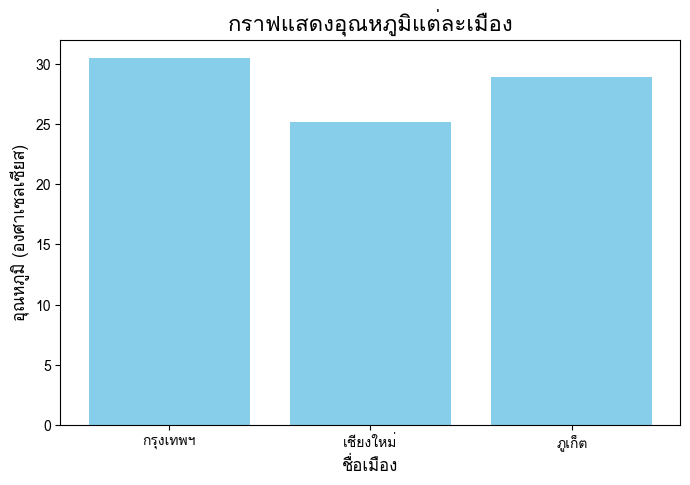

In [1]:
import pandas as pd
import numpy as np
import os, shutil
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 1. ติดตั้งฟอนต์ภาษาไทย
!apt-get -y install fonts-thai-tlwg

# 2. ล้าง cache ของ matplotlib เพื่ออัปเดตฟอนต์ใหม่
cache_dir = matplotlib.get_cachedir()
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

# 3. ลงทะเบียนฟอนต์ใหม่เข้ากับ FontManager
font_path = '/usr/share/fonts/truetype/tlwg/Loma.ttf'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)

# 4. ตั้งค่าฟอนต์หลัก
plt.rcParams['font.family'] = 'Loma'
plt.rcParams['axes.unicode_minus'] = False

# 5. สร้างข้อมูลจำลองและแสดงผล
data = {
    'เมือง': ['กรุงเทพฯ', 'เชียงใหม่', 'ภูเก็ต'],
    'อุณหภูมิ': [30.5, 25.2, 28.9]
}
df_thai = pd.DataFrame(data)

print("ตั้งค่าระบบฟอนต์ภาษาไทยสำเร็จ!")

plt.figure(figsize=(8, 5))
plt.bar(df_thai['เมือง'], df_thai['อุณหภูมิ'], color='skyblue')
plt.title('กราฟแสดงอุณหภูมิแต่ละเมือง', fontsize=16)
plt.xlabel('ชื่อเมือง', fontsize=12)
plt.ylabel('อุณหภูมิ (องศาเซลเซียส)', fontsize=12)
plt.show()

In [2]:
import pandas as pd
import numpy as np

BASE = ("https://raw.githubusercontent.com/PitchayaW/"
        "SC-612-104-Essential-Data-Science/refs/heads/main/Module-A-Notebooks/Dataset/")

df = pd.read_csv(BASE + "world_weather_sample.csv")
city_info = pd.read_csv(BASE + "city_info.csv")
region_info = pd.read_csv(BASE + "region_info.csv")

print("weather:", df.shape, " city_info:", city_info.shape, " region_info:", region_info.shape)
df.head()

weather: (2075, 10)  city_info: (23, 5)  region_info: (6, 3)


,record_id,date,city,country,region,temperature_c,humidity_pct,rainfall_mm,wind_speed_kmh,pressure_hpa
0,983,2025-03-24,New York,USA,North America,15.7,72.6,6.3,15.9,1005.4
1,220,2025-02-09,Tokyo,Japan,Asia,18.3,60.6,0.0,20.5,1015.1
2,1022,2025-02-01,Los Angeles,USA,North America,20.6,46.8,1.2,8.6,1013.5
3,469,2025-01-19,Mumbai,India,Asia,31.0,73.4,8.0,11.8,1000.1
4,1834,2025-02-03,Cape Town,South Africa,Africa,19.1,55.0,0.0,16.6,1015.1


---
## ข้อ 1 การเปรียบเทียบคำสั่งที่มีลักษณะใกล้เคียงกัน

**คำสั่ง:** ให้นักศึกษารันเซลล์โค้ดทั้ง 6 เซลล์ต่อไปนี้ สังเกตผลลัพธ์ที่ได้ แล้วอธิบายกับตนเองให้เข้าใจความแตกต่างของคำสั่งในแต่ละเซลล์ พร้อมระบุว่าในทางปฏิบัติควรเลือกใช้คำสั่งใดในสถานการณ์ใด

การอธิบายควรครอบคลุมทั้ง **ชนิดของผลลัพธ์** **รูปร่างของผลลัพธ์** และ **ความหมายของค่าที่ได้**

In [3]:
# เซลล์ 1.1
s = pd.Series([10, 20, 30], index=["a", "b", "c"])
print(s["a"])
print(s.iloc[0])
print(s[["a", "c"]])

10
10
a    10
c    30
dtype: int64


จาก #เซลล์ 1.1
คือการเปรียบเทียบการเข้าถึงข้อมูลใน series ด้วย label และตำแหน่ง


*   ใช้ s["a"] เพื่อเข้าถึงด้วย Label
*   ใช้ s.iloc[0] เพื่อ เข้าถึงด้วยตำแหน่ง
*  ใช้ s[["a","c"]]  เพื่อเข้าถึงหลาย label พร้อมกัน



In [4]:
# เซลล์ 1.2
print(type(df["city"]), df["city"].shape)
print(type(df[["city"]]), df[["city"]].shape)

<class 'pandas.core.series.Series'> (2075,)
<class 'pandas.core.frame.DataFrame'> (2075, 1)


จาก #เซลล์ 1.2
เปรียบเทียบการเลือกคอลัมน์จาก DataFrame.

* df["city"]  ให้ได้ Series (1 มิติ)

* df[["city"]]  ให้ได้ DataFrame (2 มิติ)

* สังเกต shape ต่างกัน (2075,) vs (2075,1)

In [5]:
# เซลล์ 1.3
print(df.loc[0:3].shape)
print(df.iloc[0:3].shape)

(4, 10)
(3, 10)


จาก #เซลล์ 1.3
เปรียบเทียบการเลือกแถวด้วย loc และ iloc.

* df.loc[0:3]  ทำการรวมแถว index 0 ถึง 3 (4 แถว)

* df.iloc[0:3]  ทำการเลือกตำแหน่ง 0 ถึง 2 (3 แถว)

* loc รวมค่าปลายช่วง แต่ iloc ไม่รวม

In [6]:
# เซลล์ 1.4
print(df.groupby("city")["temperature_c"].count().head(3))
print(df.groupby("city").size().head(3))

city
Auckland    90
Bangkok     91
Beijing     89
Name: temperature_c, dtype: int64
city
Auckland    90
Bangkok     91
Beijing     90
dtype: int64


จาก #เซลล์ 1.4
เปรียบเทียบการนับจำนวนข้อมูลใน groupby.

* .count() นับเฉพาะคอลัมน์ที่ระบุ

* .size() นับจำนวนแถวทั้งหมดในกลุ่ม

* ผลลัพธ์อาจต่างกันเมื่อมี missing values

In [7]:
# เซลล์ 1.5
print(df.groupby("city")["temperature_c"].mean().head(3))
print(df.groupby("city")[["temperature_c"]].mean().head(3))

city
Auckland    17.804444
Bangkok     32.453846
Beijing     15.598876
Name: temperature_c, dtype: float64
          temperature_c
city                   
Auckland      17.804444
Bangkok       32.453846
Beijing       15.598876


จาก #เซลล์ 1.5
เปรียบเทียบการใช้ mean กับ Series และ DataFrame.

* df.groupby("city")["temperature_c"].mean()  ได้ Series

* df.groupby("city")[["temperature_c"]].mean()  ได้ DataFrame

* รูปร่างผลลัพธ์ต่างกัน แต่ค่าคือค่าเฉลี่ยเหมือนกัน

In [8]:
# เซลล์ 1.6
a = pd.Series([1, 2, 3], index=["x", "y", "z"])
b = pd.Series([10, 20, 30], index=["z", "y", "x"])
print(a + b)
print(a.to_numpy() + b.to_numpy())

x    31
y    22
z    13
dtype: int64
[11 22 33]


จาก #เซลล์ 1.6
เปรียบเทียบการบวก Series ที่มี index และการบวกด้วย numpy array.

* a+b  บวกตาม index ที่ตรงกัน

* a.to_numpy()+b.to_numpy() → บวกตามตำแหน่ง ไม่สนใจ index

* ผลลัพธ์ต่างกันเมื่อ index ไม่เรียงตรงกัน

---
## ข้อ 2 Series และ DataFrame

### ตัวอย่าง

In [9]:
# การสร้าง DataFrame จากโครงสร้างข้อมูลสองรูปแบบ
d1 = pd.DataFrame({"city": ["Bangkok", "Tokyo"], "temp": [30.5, 16.2]})
d2 = pd.DataFrame([{"city": "Bangkok", "temp": 30.5}, {"city": "Tokyo", "temp": 16.2}])
print(d1.equals(d2))

# การเข้าถึงองค์ประกอบของ DataFrame
print(df.columns.tolist())
print(df.index[:5].tolist())
print(df["temperature_c"].nlargest(3).tolist())

True
['record_id', 'date', 'city', 'country', 'region', 'temperature_c', 'humidity_pct', 'rainfall_mm', 'wind_speed_kmh', 'pressure_hpa']
[0, 1, 2, 3, 4]
[999.0, 999.0, 999.0]


### โจทย์ 2.1
สร้าง Series ชื่อ `rain_by_city` ซึ่งเก็บปริมาณฝนรวมของแต่ละเมือง โดยกำหนดให้ index เป็นชื่อเมือง จากนั้นตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
2. สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด แสดงเป็นร้อยละทศนิยม 2 ตำแหน่ง
3. จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง

In [27]:
# คำตอบข้อ 2.1

# สร้าง Series rain_by_city: ผลรวมปริมาณฝนของแต่ละเมือง
rain_by_city = df.groupby("city")["rainfall_mm"].sum()

# 1) เมืองที่มีปริมาณฝนรวมสูงสุด 3 อันดับแรก
top3_rain = rain_by_city.nlargest(3)
print("3 เมืองที่มีปริมาณฝนรวมสูงสุด:")
print(top3_rain)

# 2) สัดส่วนปริมาณฝนของแต่ละเมืองเทียบกับปริมาณฝนรวมทั้งหมด (ร้อยละ ทศนิยม 2 ตำแหน่ง)
rain_share_pct = (rain_by_city / rain_by_city.sum() * 100).round(2)
print("\nสัดส่วนปริมาณฝนของแต่ละเมือง (%):")
print(rain_share_pct)

# 3) จำนวนเมืองที่มีปริมาณฝนรวมสูงกว่าค่าเฉลี่ยของทุกเมือง
mean_rain = rain_by_city.mean()
n_above_mean = (rain_by_city > mean_rain).sum()
print(f"ค่าเฉลี่ยปริมาณฝนรวมต่อเมือง: {mean_rain:.2f}")
print(f"จำนวนเมืองที่ฝนรวมสูงกว่าค่าเฉลี่ย: {n_above_mean}")

3 เมืองที่มีปริมาณฝนรวมสูงสุด:
city
Singapore    870.4
Bangkok      685.6
Lagos        652.8
Name: rainfall_mm, dtype: float64

สัดส่วนปริมาณฝนของแต่ละเมือง (%):
city
Auckland         4.22
Bangkok          8.21
Beijing          3.00
Berlin           3.21
Buenos Aires     3.65
Cairo            1.47
Cape Town        2.87
Chiang Mai       5.22
Lagos            7.82
Lima             2.16
London           3.27
Los Angeles      2.03
Mexico City      3.66
Moscow           2.96
Mumbai           5.84
Nairobi          4.74
New York         3.78
Paris            3.99
Sao Paulo        5.07
Singapore       10.43
Sydney           3.97
Tokyo            4.61
Toronto          3.81
Name: rainfall_mm, dtype: float64
ค่าเฉลี่ยปริมาณฝนรวมต่อเมือง: 362.97
จำนวนเมืองที่ฝนรวมสูงกว่าค่าเฉลี่ย: 8


/tmp/ipykernel_3736/2286554487.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rain_by_city = df.groupby("city")["rainfall_mm"].sum()


### โจทย์ 2.2
สร้าง DataFrame ชื่อ `city_profile` ที่มีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์
`city`, `country`, `region`, `n_records`, `avg_temp`, `total_rain`
โดยกำหนดให้ใช้ `groupby`

In [30]:
# คำตอบข้อ 2.2
city_profile = (
    df.groupby("city", observed=True)
    .agg(
        region=("region", "first"),
        n_records=("region", "size"),     # นับจำนวนแถวต่อเมือง
        avg_temp=("temperature_c", "mean"),
        total_rain=("rainfall_mm", "sum"),
    )
    .reset_index()
)

print(city_profile)

            city         region  n_records   avg_temp  total_rain
0       Auckland        Oceania         90  17.804444       351.9
1        Bangkok           Asia         91  32.453846       685.6
2        Beijing           Asia         90  15.598876       250.1
3         Berlin         Europe         90  12.383146       268.4
4   Buenos Aires  South America         90  19.171910       305.1
5          Cairo         Africa         91  26.089888       123.0
6      Cape Town         Africa         90  19.153409       239.3
7     Chiang Mai           Asia         91  29.680220       435.6
8          Lagos         Africa         90  29.494253       652.8
9           Lima  South America         90  21.490000       180.3
10        London         Europe         90  13.490909       273.3
11   Los Angeles  North America         90  20.657303       169.5
12   Mexico City  North America         90  19.187778       305.9
13        Moscow         Europe         91   7.233333       247.4
14        

---
## ข้อ 3 การนำเข้าข้อมูลด้วย `read_csv()`

### ตัวอย่าง

In [18]:
# พารามิเตอร์ที่ใช้บ่อย ได้แก่ usecols, nrows, parse_dates, dtype, na_values
preview = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "date", "temperature_c"],
    parse_dates=["date"],
    nrows=5,
)
print(preview.dtypes)
preview

date             datetime64[ns]
city                     object
temperature_c           float64
dtype: object


,date,city,temperature_c
0,2025-03-24,New York,15.7
1,2025-02-09,Tokyo,18.3
2,2025-02-01,Los Angeles,20.6
3,2025-01-19,Mumbai,31.0
4,2025-02-03,Cape Town,19.1


In [19]:
# การอ่านข้อมูลทีละก้อนด้วย chunksize ซึ่งคืนค่าเป็น iterator
total_rows = 0
for chunk in pd.read_csv(BASE + "world_weather_sample.csv", chunksize=500):
    total_rows += len(chunk)
print("จำนวนแถวรวม:", total_rows)

จำนวนแถวรวม: 2075


### โจทย์ 3.1
เขียนคำสั่ง `pd.read_csv()` เพียงคำสั่งเดียวที่ดำเนินการทุกข้อต่อไปนี้ให้เสร็จสิ้นตั้งแต่ขั้นตอนการนำเข้า

1. อ่านเฉพาะคอลัมน์ `date`, `city`, `region`, `temperature_c`, `humidity_pct`, `rainfall_mm`
2. แปลงคอลัมน์ `date` เป็นชนิด datetime
3. กำหนดให้ค่า `999` และ `-999` ถูกอ่านเป็นค่าว่าง
4. กำหนดชนิดข้อมูลของ `city` และ `region` เป็น `category`
5. กำหนดให้ `city` เป็น index

ให้ตรวจสอบผลด้วย `.dtypes` และ `.info()`

In [52]:
# คำตอบข้อ 3.1 (แก้ไข)
df_task31 = pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["date", "city", "region", "temperature_c", "humidity_pct", "rainfall_mm"],
    parse_dates=["date"],
    na_values=[999, -999],
    dtype={"city": "category", "region": "category"},
    index_col="city",
)
df_task31.dtypes
df_task31.info()

# df หลักที่ใช้ต่อในข้อถัดไป ต้องมีคอลัมน์ครบ (รวม country, wind_speed_kmh ฯลฯ)
df = pd.read_csv(
    BASE + "world_weather_sample.csv",
    parse_dates=["date"],
    na_values=[999, -999],
    dtype={"city": "category", "region": "category"},
)



<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB


### โจทย์ 3.2
เปรียบเทียบปริมาณหน่วยความจำที่ใช้ระหว่างตารางที่นำเข้าตามปกติกับตารางจากโจทย์ 3.1 ด้วย `.memory_usage(deep=True)`
รายงานผลเป็นร้อยละที่ลดลง และ **อธิบาย** ว่าคอลัมน์ใดมีผลต่อการลดลงมากที่สุด เพราะเหตุใด

In [32]:
# คำตอบข้อ 3.2
# ตารางแบบปกติ (import ทุกคอลัมน์ โดยไม่ระบุ dtype/na_values ใดๆ)
df_normal = pd.read_csv(BASE + "world_weather_sample.csv")

mem_normal = df_normal.memory_usage(deep=True)
mem_optimized = df.memory_usage(deep=True)

total_normal = mem_normal.sum()
total_optimized = mem_optimized.sum()

pct_reduction = (1 - total_optimized / total_normal) * 100

print(f"หน่วยความจำแบบปกติ: {total_normal:,} bytes")
print(f"หน่วยความจำแบบ optimized: {total_optimized:,} bytes")
print(f"ลดลง: {pct_reduction:.2f}%")

print("\nเปรียบเทียบรายคอลัมน์:")
print(mem_normal)
print(mem_optimized)


หน่วยความจำแบบปกติ: 571,645 bytes
หน่วยความจำแบบ optimized: 72,917 bytes
ลดลง: 87.24%

เปรียบเทียบรายคอลัมน์:
Index                132
record_id          16600
date              122425
city              116920
country           114937
region            117631
temperature_c      16600
humidity_pct       16600
rainfall_mm        16600
wind_speed_kmh     16600
pressure_hpa       16600
dtype: int64
Index             3927
date             16600
region            2590
temperature_c    16600
humidity_pct     16600
rainfall_mm      16600
dtype: int64


### โจทย์ 3.3
ใช้การอ่านข้อมูลแบบ `chunksize` เพื่อคำนวณค่าต่อไปนี้ โดยห้ามโหลดข้อมูลทั้งไฟล์เข้าหน่วยความจำพร้อมกัน และห้ามใช้ `pd.concat`

1. อุณหภูมิสูงสุดและต่ำสุดของทั้งไฟล์
2. อุณหภูมิเฉลี่ยรายเมือง

**อธิบาย:** เหตุใดการนำค่าเฉลี่ยของแต่ละก้อนมาเฉลี่ยกันอีกครั้งจึงให้ผลไม่ถูกต้อง และควรสะสมค่าใดแทนจึงจะได้ผลที่ถูกต้อง

In [34]:
# คำตอบข้อ 3.3
import pandas as pd
import numpy as np

# ตัวสะสมผลลัพธ์
global_min = np.inf
global_max = -np.inf

city_sum = {}    # เก็บผลรวมอุณหภูมิรายเมือง
city_count = {}  # เก็บจำนวนแถว (ที่ไม่ใช่ NaN) รายเมือง

for chunk in pd.read_csv(
    BASE + "world_weather_sample.csv",
    usecols=["city", "temperature_c"],
    na_values=[999, -999],
    chunksize=500,
):
    # --- ค่าสูงสุด/ต่ำสุดของทั้งไฟล์ ---
    chunk_min = chunk["temperature_c"].min()
    chunk_max = chunk["temperature_c"].max()
    if pd.notna(chunk_min):
        global_min = min(global_min, chunk_min)
    if pd.notna(chunk_max):
        global_max = max(global_max, chunk_max)

    # --- สะสมผลรวมและจำนวนรายเมือง ---
    grouped = chunk.groupby("city")["temperature_c"].agg(["sum", "count"])
    for city, row in grouped.iterrows():
        city_sum[city] = city_sum.get(city, 0) + row["sum"]
        city_count[city] = city_count.get(city, 0) + row["count"]

print("อุณหภูมิสูงสุด:", global_max)
print("อุณหภูมิต่ำสุด:", global_min)

# คำนวณค่าเฉลี่ยรายเมืองจากผลสะสม (ไม่ใช้ pd.concat)
city_mean = pd.Series(
    {city: city_sum[city] / city_count[city] for city in city_sum}
).sort_index()

print(city_mean)

อุณหภูมิสูงสุด: 39.2
อุณหภูมิต่ำสุด: -88.0
Auckland        17.804444
Bangkok         32.453846
Beijing         15.598876
Berlin          12.383146
Buenos Aires    19.171910
Cairo           26.089888
Cape Town       19.153409
Chiang Mai      29.680220
Lagos           29.494253
Lima            21.490000
London          13.490909
Los Angeles     20.657303
Mexico City     19.187778
Moscow           7.233333
Mumbai          30.872222
Nairobi         21.440000
New York        15.476667
Paris           14.752273
Sao Paulo       22.841573
Singapore       29.308989
Sydney          20.347778
Tokyo           18.414773
Toronto         11.613636
dtype: float64


---
## ข้อ 4 การสำรวจข้อมูลและการตรวจสอบคุณภาพข้อมูล

### ตัวอย่าง

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
CategoricalIndex: 2075 entries, New York to Paris
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           2075 non-null   datetime64[ns]
 1   region         2075 non-null   category      
 2   temperature_c  2052 non-null   float64       
 3   humidity_pct   1993 non-null   float64       
 4   rainfall_mm    2013 non-null   float64       
dtypes: category(1), datetime64[ns](1), float64(3)
memory usage: 69.8 KB


In [36]:
print(df.describe().round(2))
print(df.describe(include="all").iloc[:4])

                                date  temperature_c  humidity_pct  rainfall_mm
count                           2075        2052.00       1993.00      2013.00
mean   2025-02-14 12:56:33.542168576          20.41         66.82         4.15
min              2025-01-01 00:00:00         -88.00         21.50         0.00
25%              2025-01-23 00:00:00          15.40         58.60         0.30
50%              2025-02-15 00:00:00          20.00         67.10         3.50
75%              2025-03-09 00:00:00          25.62         75.50         6.60
max              2025-03-31 00:00:00          39.20        150.00        17.60
std                              NaN           7.99         13.09         3.85
        date region  temperature_c  humidity_pct  rainfall_mm
count   2075   2075         2052.0        1993.0       2013.0
unique   NaN      6            NaN           NaN          NaN
top      NaN   Asia            NaN           NaN          NaN
freq     NaN    542            NaN       

In [37]:
print(df.isna().sum())
print("จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์:", df.isna().any(axis=1).sum())
print("จำนวนแถวที่ซ้ำกันทุกคอลัมน์:", df.duplicated().sum())

date              0
region            0
temperature_c    23
humidity_pct     82
rainfall_mm      62
dtype: int64
จำนวนแถวที่มีค่าว่างอย่างน้อยหนึ่งคอลัมน์: 164
จำนวนแถวที่ซ้ำกันทุกคอลัมน์: 5


### โจทย์ 4.1
สร้าง DataFrame ชื่อ `summary` ที่มีหนึ่งแถวต่อหนึ่งคอลัมน์ของ `df` ประกอบด้วย
`dtype`, `n_missing`, `pct_missing`, `n_unique`, `example_value`
โดยห้ามใช้การวนซ้ำทีละคอลัมน์ และให้เรียงลำดับจากคอลัมน์ที่มีค่าว่างมากที่สุด

In [46]:
# คำตอบข้อ 4.1
n = len(df)

summary = pd.DataFrame({
    "dtype": df.dtypes,
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().sum() / n * 100).round(2),
    "n_unique": df.nunique(),
    "example_value": df.apply(lambda col: col.dropna().iloc[0] if col.notna().any() else None)
}).sort_values("n_missing", ascending=False)

print(summary)

                        dtype  n_missing  pct_missing  n_unique  \
humidity_pct          float64         82         3.95       544   
rainfall_mm           float64         62         2.99       164   
temperature_c         float64         23         1.11       330   
date           datetime64[ns]          0         0.00        90   
region               category          0         0.00         6   
country                object          0         0.00        21   

                     example_value  
humidity_pct                  72.6  
rainfall_mm                    6.3  
temperature_c                 15.7  
date           2025-03-24 00:00:00  
region               North America  
country                        USA  


### โจทย์ 4.2
ผลลัพธ์ของ `.describe()` แสดงค่าสูงสุดของ `temperature_c` และ `humidity_pct` ที่เป็นไปไม่ได้ในทางกายภาพ ให้เขียนโปรแกรมหาค่าต่อไปนี้

1. จำนวนแถวที่ `temperature_c` อยู่นอกช่วง -60 ถึง 60
2. จำนวนแถวที่ `humidity_pct` อยู่นอกช่วง 0 ถึง 100
3. จำนวนแถวที่มีความผิดปกติอย่างน้อยหนึ่งคอลัมน์ โดยระวังการนับซ้ำ

In [47]:
# คำตอบข้อ 4.2
temp_bad = ~df["temperature_c"].between(-60, 60)
humid_bad = ~df["humidity_pct"].between(0, 100)

n_temp_bad = temp_bad.sum()
n_humid_bad = humid_bad.sum()
n_any_bad = (temp_bad | humid_bad).sum()   # OR แบบ boolean กัน double count

print("temperature_c ผิดปกติ:", n_temp_bad)
print("humidity_pct ผิดปกติ:", n_humid_bad)
print("แถวที่ผิดปกติอย่างน้อย 1 คอลัมน์:", n_any_bad)

temperature_c ผิดปกติ: 25
humidity_pct ผิดปกติ: 85
แถวที่ผิดปกติอย่างน้อย 1 คอลัมน์: 109


### โจทย์ 4.3
คอลัมน์ `country` มีจำนวนค่าไม่ซ้ำมากกว่าจำนวนประเทศที่มีอยู่จริง เนื่องจากการใช้ตัวพิมพ์ไม่สม่ำเสมอ

1. แสดงว่าค่าใดบ้างที่หมายถึงประเทศเดียวกันแต่ถูกนับแยกจากกัน
2. ทดลองใช้ `df["country"].str.title()` แล้ว **อธิบาย** ว่าวิธีนี้ทำให้ข้อมูลของประเทศใดเสียหาย และเพราะเหตุใด
3. เสนอและเขียนวิธี normalize ที่ถูกต้อง โดยต้องรองรับกรณีที่มีช่องว่างหัวท้ายด้วย

> **การตรวจสอบคำตอบ:** จำนวนประเทศที่ถูกต้องคือ 21 ประเทศ จากทั้งหมด 23 เมือง

In [199]:
# คำตอบข้อ 4.3
dup_groups = (
    df["country"]
    .dropna()
    .drop_duplicates()
    .to_frame()
    .assign(key=lambda x: x["country"].str.strip().str.lower())
    .groupby("key")["country"]
    .agg(list)
)

dup_groups = dup_groups[dup_groups.apply(len) > 1]
print(dup_groups)

print(df["country"].str.title().unique())

def normalize_country(s: pd.Series) -> pd.Series:
    s_clean = s.str.strip()
    # แผนที่ตัวย่อ/รูปแบบพิเศษที่ title() จะทำลาย ให้คงไว้ตามที่ถูกต้อง
    special_cases = {
        "usa": "USA",
        "uk": "UK",
        # เพิ่มเคสอื่นตามที่พบในข้อมูลจริง
    }
    lower_key = s_clean.str.lower()
    normalized = lower_key.map(special_cases).fillna(s_clean.str.title())
    return normalized

df["country_clean"] = normalize_country(df["country"])
print(df["country_clean"].nunique())

key
argentina          [Argentina, ARGENTINA]
canada                   [Canada, CANADA]
germany                [Germany, GERMANY]
japan                      [Japan, JAPAN]
kenya                      [Kenya, KENYA]
new zealand    [New Zealand, NEW ZEALAND]
singapore          [Singapore, SINGAPORE]
Name: country, dtype: object
['Usa' 'Japan' 'India' 'South Africa' 'New Zealand' 'Argentina' 'Mexico'
 'Russia' 'Kenya' 'China' 'Australia' 'Nigeria' 'Peru' 'France'
 'Singapore' 'Egypt' 'Uk' 'Thailand' 'Germany' 'Brazil' 'Canada']
21


---
## ข้อ 5 การเลือกข้อมูลด้วย `loc` และ `iloc`

### ตัวอย่าง

In [87]:
# iloc อ้างอิงตามตำแหน่ง ส่วน loc อ้างอิงตาม label และรวมค่าปลายช่วง
print(df.iloc[0:3, 0:3].shape, df.loc[0:3, ["city", "region"]].shape)

# loc ใช้ร่วมกับเงื่อนไขและเลือกคอลัมน์ได้ในคำสั่งเดียว
print(df.loc[df["temperature_c"] > 35, ["city", "date", "temperature_c"]].head(3))

(3, 3) (4, 2)
           city       date  temperature_c
325      Mumbai 2025-03-31           35.6
350   Singapore 2025-03-23           35.4
492  Chiang Mai 2025-03-29           35.6


In [88]:
# การกำหนด index หลายระดับ และการเลือกข้อมูลจาก index หลายระดับ
multi = df.set_index(["region", "city"]).sort_index()
print(multi.loc["Asia"].shape)
print(multi.loc[("Asia", "Tokyo"), ["date", "temperature_c"]].head(3))

(540, 21)
                   date  temperature_c
region city                           
Asia   Tokyo 2025-02-09           18.3
       Tokyo 2025-03-21           19.7
       Tokyo 2025-03-23           17.7


### โจทย์ 5.1
ใช้ `.iloc[]` เท่านั้น โดยห้ามอ้างอิงชื่อคอลัมน์ เพื่อดึงข้อมูลต่อไปนี้

1. แถวที่อยู่ในตำแหน่งเลขคู่ 10 แถวแรก เฉพาะสามคอลัมน์สุดท้าย
2. ห้าแถวสุดท้าย โดยเรียงลำดับจากแถวล่างสุดขึ้นไป
3. ค่าเดี่ยวที่อยู่ในแถวกึ่งกลางตารางและคอลัมน์สุดท้าย โดยต้องคำนวณตำแหน่งกึ่งกลางจากจำนวนแถว

In [89]:
# คำตอบข้อ 5.1
# 1) แถวตำแหน่งเลขคู่ 10 แถวแรก (0,2,4,...,18) เฉพาะสามคอลัมน์สุดท้าย
even10 = df.iloc[0:20:2, -3:]
print(even10)

# 2) ห้าแถวสุดท้าย เรียงจากล่างขึ้นบน
last5_reversed = df.iloc[-1:-6:-1]
print(last5_reversed)

# 3) ค่าเดี่ยวกึ่งกลางตาราง คอลัมน์สุดท้าย (คำนวณตำแหน่งกึ่งกลางจากจำนวนแถวจริง)
mid_row = (len(df) - 1) // 2
mid_value = df.iloc[mid_row, -1]
print(mid_row, mid_value)

    rain_rank_average  rain_rank_min  rain_rank_dense
0                19.0           19.0             17.0
2                40.5           40.0             30.0
4                73.0           59.0             40.0
6                43.0           42.0             35.0
8                53.0           53.0             43.0
10               71.5           57.0             45.0
12               74.5           61.0             45.0
14               49.0           49.0             40.0
16               12.0           12.0             11.0
18               28.0           28.0             24.0
      record_id       date         city country         region  temperature_c  \
2074      642.0 2025-01-12        Paris  France         Europe           11.1   
2073     1210.0 2025-02-09      Toronto  Canada  North America            NaN   
2072     1738.0 2025-01-28      Nairobi   Kenya         Africa           21.7   
2071     1769.0 2025-02-28      Nairobi   Kenya         Africa           20.6   
2

### โจทย์ 5.2
จาก DataFrame ที่กำหนด index เป็นคู่ `(region, city)` ให้ดึงข้อมูลต่อไปนี้ด้วย `.loc[]`

1. ข้อมูลทั้งหมดของภูมิภาค Asia เฉพาะคอลัมน์ `date` และ `temperature_c`
2. ข้อมูลของเมือง Tokyo และ Bangkok พร้อมกันในคำสั่งเดียว
3. ข้อมูลของทุกภูมิภาค แต่เฉพาะเมืองที่ชื่อขึ้นต้นด้วยตัวอักษร B

**อธิบาย:** เหตุใดจึงควรเรียงลำดับ index ด้วย `.sort_index()` ก่อนใช้งาน index หลายระดับ

In [90]:
# คำตอบข้อ 5.2

multi = df.set_index(["region", "city"]).sort_index()

# 1) ภูมิภาค Asia เฉพาะคอลัมน์ date และ temperature_c
asia_dt = multi.loc["Asia", ["date", "temperature_c"]]
print(asia_dt.shape)

# 2) เมือง Tokyo และ Bangkok พร้อมกัน
tokyo_bkk = multi.loc[(slice(None), ["Tokyo", "Bangkok"]), :]
print(tokyo_bkk.shape)

# 3) ทุกภูมิภาค เฉพาะเมืองที่ขึ้นต้นด้วย B
starts_b = multi.loc[(slice(None), multi.index.get_level_values("city").str.startswith("B")), :]
print(starts_b.index.get_level_values("city").unique().tolist())

(540, 2)
(180, 21)
['Bangkok', 'Beijing', 'Berlin', 'Buenos Aires']


### โจทย์ 5.3
ให้รันโปรแกรมต่อไปนี้ แล้วสังเกตผลที่เกิดขึ้นกับ `df`

```python
subset = df[df["city"] == "Bangkok"]
subset["temperature_c"] = 0
```

จากนั้นเขียนโปรแกรมที่ถูกต้องสองรูปแบบ ได้แก่ รูปแบบที่ต้องการแก้ไข `df` จริง และรูปแบบที่ต้องการทำงานกับสำเนาแยกต่างหาก
พร้อมสรุปเป็นแนวปฏิบัติของตนเองความยาว 2 ถึง 3 บรรทัด

In [91]:
# คำตอบข้อ 5.3
# รันแล้วจะเห็น SettingWithCopyWarning เพราะ subset อาจเป็นแค่ view ของ df ไม่ใช่สำเนาจริง
# pandas ไม่การันตีว่าการแก้ subset จะกระทบ df เดิมหรือไม่ -> พฤติกรรมไม่แน่นอน (ambiguous)

# แบบที่ 1: ต้องการแก้ไข df จริง ใช้ .loc[] กับเงื่อนไขตรงตัวแปรเดิม
df.loc[df["city"] == "Bangkok", "temperature_c"] = 0

# แบบที่ 2: ต้องการสำเนาแยกต่างหาก ใช้ .copy() ให้ชัดเจน
subset = df[df["city"] == "Bangkok"].copy()
subset["temperature_c"] = 0

# เหตุใดจึงควรเรียงลำดับ index ด้วย .sort_index() ก่อนใช้งาน index หลายระดับ
ต้อง .sort_index() ก่อน เพราะการ slice ด้วย multi-index (เช่น .loc["Asia"] หรือใช้ slice(None)) ต้องการให้ index เรียงลำดับ (lexicographically sorted) มิฉะนั้น pandas จะ raise UnsortedIndexError หรือให้ผลลัพธ์ที่ไม่ครบถ้วน/ไม่ตรงตามที่คาด เพราะการค้นหาแบบ binary search บน index ทำงานถูกต้องเฉพาะเมื่อเรียงลำดับแล้วเท่านั้น

---
## ข้อ 6 การกรองข้อมูลด้วยเงื่อนไข

### ตัวอย่าง

In [92]:
# การใช้ตัวดำเนินการ & | ~ ต้องครอบวงเล็บทุกเงื่อนไข
print(len(df[(df["temperature_c"] > 28) & (df["humidity_pct"] > 70)]))
print(len(df[~df["city"].isin(["Bangkok", "Tokyo"])]))
print(len(df[df["temperature_c"].between(20, 30)]))
print(len(df.query("region == 'Asia' and rainfall_mm > 5")))

174
1890
738
293


In [93]:
# where และ mask ไม่ลดจำนวนแถว แต่แทนค่าที่ไม่ตรงเงื่อนไขด้วยค่าที่กำหนด
temp_valid = df["temperature_c"].where(df["temperature_c"].between(-60, 60))
rain_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > 15, 15)
print(temp_valid.isna().sum(), df["temperature_c"].isna().sum())
print(rain_capped.max(), df["rainfall_mm"].max())

25 23
15.0 17.6


In [94]:
# pipe ใช้ต่อขั้นตอนการประมวลผลหลายขั้นให้เป็นลำดับเดียว
def add_flag(data, threshold):
    return data.assign(is_hot=data["temperature_c"] > threshold)

result = (df
          .query("region == 'Asia'")
          .pipe(add_flag, threshold=30)
          .loc[:, ["city", "temperature_c", "is_hot"]])
print(result.head(3))

       city  temperature_c  is_hot
1     Tokyo           18.3   False
3    Mumbai           31.0    True
12  Beijing           14.3   False


### โจทย์ 6.1
เขียนเงื่อนไขสำหรับกรองข้อมูลต่อไปนี้

1. ข้อมูลในภูมิภาคเอเชียที่ปริมาณฝนมากกว่า 5 มิลลิเมตร และความเร็วลมมากกว่า 20 กิโลเมตรต่อชั่วโมง
2. ข้อมูลที่ไม่ใช่เมือง Bangkok, Tokyo และ London และมีความชื้นระหว่าง 40 ถึง 60
3. แถวที่มีค่าว่างตั้งแต่ 2 คอลัมน์ขึ้นไป
4. แถวที่ชื่อเมืองมีคำว่า New หรือ San ประกอบอยู่ โดยใช้ `.str.contains` ร่วมกับ regular expression

In [95]:
# คำตอบข้อ 6.1
cond1 = df[(df["region"] == "Asia") & (df["rainfall_mm"] > 5) & (df["wind_speed_kmh"] > 20)]

cond2 = df[(~df["city"].isin(["Bangkok", "Tokyo", "London"])) & (df["humidity_pct"].between(40, 60))]

cond3 = df[df.isna().sum(axis=1) >= 2]

cond4 = df[df["city"].astype(str).str.contains(r"New|San", regex=True)]

print(len(cond1), len(cond2), len(cond3), len(cond4))
print(cond4["city"].unique())

53 469 97 90
['New York']
Categories (23, object): ['Auckland', 'Bangkok', 'Beijing', 'Berlin', ..., 'Singapore', 'Sydney',
                          'Tokyo', 'Toronto']


### โจทย์ 6.2
ใช้ `.where()` และ `.mask()` สร้างคอลัมน์ใหม่สองคอลัมน์ ได้แก่ คอลัมน์อุณหภูมิที่แทนค่าผิดปกติด้วยค่าว่าง และคอลัมน์ปริมาณฝนที่จำกัดค่าสูงสุดไว้ที่ค่าเปอร์เซ็นไทล์ที่ 99
**อธิบาย:** แนวทางนี้แตกต่างจากการลบแถวทิ้งอย่างไรในแง่ของการวิเคราะห์ในขั้นถัดไป

In [96]:
# คำตอบข้อ 6.2
temp_clean = df["temperature_c"].where(df["temperature_c"].between(-60, 60))

p99 = df["rainfall_mm"].quantile(0.99)
rain_capped = df["rainfall_mm"].mask(df["rainfall_mm"] > p99, p99)

df["temperature_c_clean"] = temp_clean
df["rainfall_mm_capped"] = rain_capped

#อธิบาย
.where()/.mask() คงจำนวนแถวเดิมไว้ทั้งหมด เพียงแทนค่าที่ผิดเงื่อนไขด้วยค่าว่างหรือค่าที่กำหนด ต่างจากการ dropna()/filter ทิ้งแถว ซึ่งจะลดจำนวนตัวอย่างและอาจทำให้เสียข้อมูลของคอลัมน์อื่นในแถวเดียวกันไปด้วย วิธีนี้เหมาะเมื่อค่าผิดปกติกระจุกอยู่แค่บางคอลัมน์ เพราะรักษาข้อมูลคอลัมน์อื่นของแถวนั้นไว้ให้ใช้ในการวิเคราะห์ต่อได้

### โจทย์ 6.3
หาวันที่มีอุณหภูมิห่างจากค่าเฉลี่ยของเมืองตนเองมากที่สุดของแต่ละเมือง
ผลลัพธ์ต้องมีหนึ่งแถวต่อหนึ่งเมือง ประกอบด้วยคอลัมน์ `city`, `date`, `temperature_c`, `deviation`

In [97]:
# คำตอบข้อ 6.3
city_mean = df.groupby("city", observed=True)["temperature_c"].transform("mean")
deviation = (df["temperature_c"] - city_mean).abs()

idx_max = deviation.groupby(df["city"], observed=True).idxmax()
result = df.loc[idx_max.dropna(), ["city", "date", "temperature_c"]].copy()
result["deviation"] = deviation.loc[idx_max.dropna()].values
print(result)

              city       date  temperature_c   deviation
1036      Auckland 2025-02-27           25.6    7.795556
67         Bangkok 2025-02-22            0.0    0.000000
1778       Beijing 2025-03-06           22.6    7.001124
1224        Berlin 2025-03-26           19.4    7.016854
1280  Buenos Aires 2025-01-19          -88.0  107.171910
94           Cairo 2025-03-31           33.6    7.529545
1888     Cape Town 2025-03-23           25.5    6.346591
2066    Chiang Mai 2025-03-28           37.3    7.650000
552          Lagos 2025-01-01           21.1    8.394253
34            Lima 2025-01-22           12.9    8.590000
747         London 2025-02-09           23.4    9.909091
62     Los Angeles 2025-01-09           13.4    7.257303
1735   Mexico City 2025-02-24           26.5    7.312222
994         Moscow 2025-01-20           -0.2    7.392135
589         Mumbai 2025-01-07           24.2    6.672222
1157       Nairobi 2025-03-11           27.8    6.370787
1834      New York 2025-03-16  

---
## ข้อ 7 การจัดการข้อมูลวันที่และเวลา

### ตัวอย่าง

In [98]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"].dt.month.head(3).tolist())
print(df["date"].dt.day_name().head(3).tolist())
print(df["date"].min(), df["date"].max())

# assign ใช้สร้างหลายคอลัมน์ในคำสั่งเดียวและคืนค่าเป็น DataFrame ใหม่
tmp = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(tmp[["date", "year_month", "is_weekend"]].head(3))

[3, 2, 2]
['Monday', 'Sunday', 'Saturday']
2025-01-01 00:00:00 2025-03-31 00:00:00
        date year_month  is_weekend
0 2025-03-24    2025-03       False
1 2025-02-09    2025-02        True
2 2025-02-01    2025-02        True


In [ ]:
# resample สรุปข้อมูลตามช่วงเวลา โดยต้องกำหนด index เป็น datetime ก่อน
bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
print(bkk["temperature_c"].resample("7D").mean().head(4).round(2))

date
2025-01-01    30.36
2025-01-08    31.09
2025-01-15    30.39
2025-01-22    32.29
Freq: 7D, Name: temperature_c, dtype: float64


### โจทย์ 7.1
ใช้ `.assign()` เพียงคำสั่งเดียวสร้างคอลัมน์ `year_month`, `week_of_year`, `day_name` และ `is_weekend`

In [99]:
# คำตอบข้อ 7.1

df = df.assign(
    year_month=df["date"].dt.to_period("M").astype(str),
    week_of_year=df["date"].dt.isocalendar().week,
    day_name=df["date"].dt.day_name(),
    is_weekend=df["date"].dt.dayofweek >= 5,
)
print(df[["date", "year_month", "week_of_year", "day_name", "is_weekend"]].head())

        date year_month  week_of_year  day_name  is_weekend
0 2025-03-24    2025-03            13    Monday       False
1 2025-02-09    2025-02             6    Sunday        True
2 2025-02-01    2025-02             5  Saturday        True
3 2025-01-19    2025-01             3    Sunday        True
4 2025-02-03    2025-02             6    Monday       False


### โจทย์ 7.2
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. ข้อมูลครอบคลุมทั้งหมดกี่วัน และมีวันใดในช่วงดังกล่าวที่ไม่มีข้อมูลเลยหรือไม่ โดยใช้ `pd.date_range` ประกอบการตรวจสอบ
2. อุณหภูมิเฉลี่ยของวันหยุดสุดสัปดาห์เปรียบเทียบกับวันธรรมดา จำแนกตามภูมิภาค
3. เดือนที่มีปริมาณฝนรวมสูงสุดของแต่ละเมือง

In [100]:
# คำตอบข้อ 7.2
# 1) ครอบคลุมกี่วัน และมีวันไหนขาดหายไปหรือไม่
n_days_span = (df["date"].max() - df["date"].min()).days + 1
full_range = pd.date_range(df["date"].min(), df["date"].max(), freq="D")
missing_days = full_range.difference(df["date"].unique())
print("จำนวนวันทั้งหมดในช่วง:", n_days_span, " วันที่ไม่มีข้อมูลเลย:", len(missing_days))

# 2) อุณหภูมิเฉลี่ยวันหยุด vs วันธรรมดา จำแนกตามภูมิภาค
weekend_compare = df.groupby(["region", "is_weekend"], observed=True)["temperature_c"].mean().round(2)
print(weekend_compare)

# 3) เดือนที่ฝนรวมสูงสุดของแต่ละเมือง
month_rain = df.groupby(["city", df["date"].dt.month], observed=True)["rainfall_mm"].sum()
top_month_per_city = month_rain.groupby("city", observed=True).idxmax()
print(top_month_per_city.head())


จำนวนวันทั้งหมดในช่วง: 90  วันที่ไม่มีข้อมูลเลย: 0
region         is_weekend
Africa         False         24.06
               True          23.90
Asia           False         20.45
               True          21.12
Europe         False         11.94
               True          11.95
North America  False         16.72
               True          16.84
Oceania        False         18.94
               True          19.40
South America  False         21.70
               True          19.84
Name: temperature_c, dtype: float64
city
Auckland            (Auckland, 3)
Bangkok              (Bangkok, 2)
Beijing              (Beijing, 2)
Berlin                (Berlin, 3)
Buenos Aires    (Buenos Aires, 2)
Name: rainfall_mm, dtype: object


### โจทย์ 7.3
ใช้ `.resample()` สรุปข้อมูลของเมือง Bangkok เป็นราย 7 วัน โดยแสดงอุณหภูมิเฉลี่ยและปริมาณฝนรวมในตารางเดียวกัน
**อธิบาย:** `.resample()` แตกต่างจาก `groupby(df["date"].dt.month)` อย่างไร และกรณีใดที่จำเป็นต้องใช้ `.resample()` เท่านั้น

In [101]:
# คำตอบข้อ 7.3

bkk = df[df["city"] == "Bangkok"].set_index("date").sort_index()
bkk_weekly = bkk.resample("7D").agg(avg_temp=("temperature_c", "mean"), total_rain=("rainfall_mm", "sum"))
print(bkk_weekly.round(2))

            avg_temp  total_rain
date                            
2025-01-01       0.0        65.7
2025-01-08       0.0        47.6
2025-01-15       0.0        58.7
2025-01-22       0.0        50.0
2025-01-29       0.0        55.4
2025-02-05       0.0        65.1
2025-02-12       0.0        60.2
2025-02-19       0.0        42.5
2025-02-26       0.0        56.1
2025-03-05       0.0        49.1
2025-03-12       0.0        56.4
2025-03-19       0.0        41.9
2025-03-26       0.0        31.3


---
## ข้อ 8 การจัดการค่าว่างและข้อมูลซ้ำ

### ตัวอย่าง

In [102]:
# การเติมค่าว่างด้วยค่าสถิติของกลุ่มตนเอง โดยใช้ transform
filled_by_city = df["temperature_c"].fillna(
    df.groupby("city")["temperature_c"].transform("mean")
)
print(df["temperature_c"].isna().sum(), "->", filled_by_city.isna().sum())

# การเติมค่าด้วยค่าของวันก่อนหน้าภายในเมืองเดียวกัน
sorted_df = df.sort_values(["city", "date"])
ffilled = sorted_df.groupby("city")["temperature_c"].ffill()
print("หลังเติมแบบ ffill เหลือค่าว่าง:", ffilled.isna().sum())

23 -> 0
หลังเติมแบบ ffill เหลือค่าว่าง: 0


/tmp/ipykernel_3736/1444335474.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("city")["temperature_c"].transform("mean")
/tmp/ipykernel_3736/1444335474.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ffilled = sorted_df.groupby("city")["temperature_c"].ffill()


In [103]:
# การตรวจสอบข้อมูลซ้ำตามคีย์ที่กำหนด
print("ซ้ำทุกคอลัมน์:", df.duplicated().sum())
print("ซ้ำตามคีย์ (city, date):", df.duplicated(subset=["city", "date"]).sum())
print("จำนวนแถวหลังขจัดข้อมูลซ้ำ:", df.drop_duplicates().shape[0])

ซ้ำทุกคอลัมน์: 0
ซ้ำตามคีย์ (city, date): 0
จำนวนแถวหลังขจัดข้อมูลซ้ำ: 2070


### โจทย์ 8.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. คอลัมน์ใดมีค่าว่างมากที่สุด และคิดเป็นร้อยละเท่าใด
2. ค่าว่างกระจายตัวเท่ากันทุกเมืองหรือไม่ ให้สร้างตารางแสดงสัดส่วนค่าว่างของ `temperature_c` จำแนกตามเมือง
3. หากลบทุกแถวที่มีค่าว่างด้วย `dropna()` จะเหลือข้อมูลคิดเป็นร้อยละเท่าใดของข้อมูลเดิม และเมืองใดสูญเสียข้อมูลมากที่สุด

In [104]:
# คำตอบข้อ 8.1

na_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
print(na_pct.head(1))  # humidity_pct มีค่าว่างมากที่สุด

na_by_city = (df.groupby("city", observed=True)["temperature_c"]
                .apply(lambda s: s.isna().mean() * 100)
                .round(2))
print(na_by_city)

dropped = df.dropna()
pct_remaining = round(len(dropped) / len(df) * 100, 2)
loss_by_city = df.groupby("city", observed=True).size() - dropped.groupby("city", observed=True).size()
print("เหลือ:", pct_remaining, "% เมืองที่เสียข้อมูลมากสุด:", loss_by_city.idxmax(), loss_by_city.max())

temp_z    5.458937
dtype: float64
city
Auckland        0.00
Bangkok         0.00
Beijing         1.11
Berlin          1.11
Buenos Aires    1.11
Cairo           2.22
Cape Town       2.22
Chiang Mai      0.00
Lagos           3.33
Lima            0.00
London          2.22
Los Angeles     1.11
Mexico City     0.00
Moscow          1.11
Mumbai          0.00
Nairobi         1.11
New York        0.00
Paris           2.22
Sao Paulo       1.11
Singapore       1.11
Sydney          0.00
Tokyo           2.22
Toronto         2.22
Name: temperature_c, dtype: float64
เหลือ: 84.93 % เมืองที่เสียข้อมูลมากสุด: Auckland 14.0


### โจทย์ 8.2
เติมค่าว่างของ `temperature_c` ด้วยสามวิธี ได้แก่ ค่าเฉลี่ยรวมทั้งตาราง ค่าเฉลี่ยของเมืองตนเอง และค่าของวันก่อนหน้าภายในเมืองเดียวกัน
จากนั้นเปรียบเทียบผลกระทบต่อค่าเฉลี่ยและส่วนเบี่ยงเบนมาตรฐานรายเมืองในรูปตารางเดียว

**อธิบาย:** วิธีใดเหมาะสมที่สุดกับข้อมูลชุดนี้ และวิธีใดทำให้ความแปรปรวนของข้อมูลลดลงอย่างผิดธรรมชาติ

In [105]:
# คำตอบข้อ 8.2
fill_overall = df["temperature_c"].fillna(df["temperature_c"].mean())
fill_by_city = df["temperature_c"].fillna(df.groupby("city", observed=True)["temperature_c"].transform("mean"))
fill_ffill = (df.sort_values(["city", "date"])
                .groupby("city", observed=True)["temperature_c"]
                .ffill())

compare = pd.DataFrame({
    "ต้นฉบับ": df.groupby("city", observed=True)["temperature_c"].agg(["mean", "std"]).stack(),
    "เติมค่าเฉลี่ยรวม": fill_overall.groupby(df["city"], observed=True).agg(["mean", "std"]).stack(),
    "เติมค่าเฉลี่ยรายเมือง": fill_by_city.groupby(df["city"], observed=True).agg(["mean", "std"]).stack(),
    "เติมด้วย ffill": fill_ffill.groupby(df["city"], observed=True).agg(["mean", "std"]).stack(),
})
print(compare.round(2))


                   ต้นฉบับ  เติมค่าเฉลี่ยรวม  เติมค่าเฉลี่ยรายเมือง  \
city                                                                  
Auckland     mean    17.80             17.80                  17.80   
             std      2.80              2.80                   2.80   
Bangkok      mean     0.00              0.00                   0.00   
             std      0.00              0.00                   0.00   
Beijing      mean    15.60             15.64                  15.60   
             std      2.87              2.88                   2.86   
Berlin       mean    12.38             12.46                  12.38   
             std      2.60              2.67                   2.58   
Buenos Aires mean    19.17             19.17                  19.17   
             std     11.82             11.75                  11.75   
Cairo        mean    26.07             25.91                  26.07   
             std      2.74              2.91                   2.71   
Cape T

#อธิบาย
 การเติมด้วย ค่าเฉลี่ยรายเมือง เหมาะสมที่สุดกับข้อมูลชุดนี้ เพราะแต่ละเมืองมีสภาพอากาศเฉพาะตัวต่างกันมาก การใช้ค่าเฉลี่ยรวมทั้งตารางจะดึงค่าของเมืองหนาว/ร้อนเข้าใกล้ค่ากลางผิดธรรมชาติ ส่วนการเติมด้วย ค่าเฉลี่ย (ไม่ว่ารวมหรือรายเมือง) ทำให้ส่วนเบี่ยงเบนมาตรฐาน (std) ลดลงผิดธรรมชาติ เพราะค่าที่เติมทุกค่าเท่ากับค่ากลางพอดี ไม่มีความแปรปรวนของตัวเอง ในขณะที่ ffill ยังคงรักษาความแปรปรวนตามธรรมชาติของข้อมูลไว้ได้ดีกว่า

### โจทย์ 8.3
ข้อมูลชุดนี้ควรมีหนึ่งแถวต่อหนึ่งเมืองต่อหนึ่งวัน ให้ตรวจสอบว่าเป็นจริงหรือไม่

1. มีคู่ `(city, date)` ที่ซ้ำกันจำนวนกี่คู่
2. แถวที่ซ้ำเป็นการซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์แต่ค่าที่วัดได้ต่างกัน ให้แสดงหลักฐานประกอบ
3. เขียนโปรแกรมขจัดข้อมูลซ้ำ พร้อมระบุนโยบายที่เลือกใช้ แล้วตรวจสอบว่าจำนวนแถวที่เหลือเท่ากับจำนวนเมืองคูณจำนวนวัน

> **การตรวจสอบคำตอบ:** หลังขจัดข้อมูลซ้ำต้องเหลือ 2070 แถว ซึ่งเท่ากับ 23 เมือง คูณ 90 วัน

In [106]:
# คำตอบข้อ 8.3
# 1) จำนวนคู่ (city, date) ที่ซ้ำกัน
dup_mask = df.duplicated(subset=["city", "date"], keep=False)
n_dup_pairs = dup_mask.sum() // 2
print("จำนวนคู่ที่ซ้ำ:", n_dup_pairs)

# 2) หลักฐาน: ซ้ำทุกคอลัมน์ หรือซ้ำเฉพาะคีย์
dup_rows = df[dup_mask].sort_values(["city", "date"])
print(dup_rows[["city", "date", "temperature_c", "rainfall_mm"]])
print("จำนวนที่ซ้ำทุกคอลัมน์:", df.duplicated().sum())

# 3) ขจัดข้อมูลซ้ำ (นโยบาย: เก็บแถวแรกที่พบ เพราะซ้ำทุกคอลัมน์อยู่แล้ว ไม่มีค่าใหม่กว่าให้เลือก)
df = df.drop_duplicates().copy()
print(df.shape[0], "==", df["city"].nunique() * 90)

จำนวนคู่ที่ซ้ำ: 0
Empty DataFrame
Columns: [city, date, temperature_c, rainfall_mm]
Index: []
จำนวนที่ซ้ำทุกคอลัมน์: 0
2070 == 2070


---
## ข้อ 9 การสรุปข้อมูลด้วย `groupby()` และ `agg()`

ตั้งแต่ข้อนี้เป็นต้นไป ให้ใช้ตารางที่ขจัดข้อมูลซ้ำแล้วเป็นข้อมูลตั้งต้น

In [107]:
df = df.drop_duplicates().copy()
df["month"] = df["date"].dt.month
print(df.shape)

(2070, 23)


### ตัวอย่าง

In [108]:
# named aggregation ช่วยให้กำหนดชื่อคอลัมน์ผลลัพธ์ได้โดยตรง
summary = df.groupby("city").agg(
    avg_temp=("temperature_c", "mean"),
    total_rain=("rainfall_mm", "sum"),
    max_wind=("wind_speed_kmh", "max"),
    n_days=("temperature_c", "count"),
)
print(summary.head(3).round(2))

# การใช้ฟังก์ชันที่นิยามเองภายใน agg
heavy = df.groupby("city").agg(
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
)
print(heavy.head(3))

          avg_temp  total_rain  max_wind  n_days
city                                            
Auckland      17.8       351.9      26.0      90
Bangkok        0.0       680.0      29.8      90
Beijing       15.6       250.1      27.6      89
          heavy_rain_days
city                     
Auckland                6
Bangkok                23
Beijing                 2


/tmp/ipykernel_3736/585541396.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = df.groupby("city").agg(
/tmp/ipykernel_3736/585541396.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heavy = df.groupby("city").agg(


### โจทย์ 9.1
สร้างตารางสรุปรายเมืองในคำสั่ง `agg()` เดียว ประกอบด้วยคอลัมน์ต่อไปนี้

| คอลัมน์ | ความหมาย |
|---|---|
| `avg_temp`, `median_temp`, `std_temp` | สถิติของอุณหภูมิ |
| `total_rain` | ปริมาณฝนรวม |
| `heavy_rain_days` | จำนวนวันที่ฝนมากกว่า 10 มิลลิเมตร |
| `pct_missing_temp` | สัดส่วนวันที่อุณหภูมิเป็นค่าว่าง |

In [109]:

# คำตอบข้อ 9.1
summary = df.groupby("city", observed=True).agg(
    avg_temp=("temperature_c", "mean"),
    median_temp=("temperature_c", "median"),
    std_temp=("temperature_c", "std"),
    total_rain=("rainfall_mm", "sum"),
    heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()),
    pct_missing_temp=("temperature_c", lambda s: s.isna().mean() * 100),
)
print(summary.round(2))

              avg_temp  median_temp  std_temp  total_rain  heavy_rain_days  \
city                                                                         
Auckland         17.80        17.55      2.80       351.9                6   
Bangkok           0.00         0.00      0.00       680.0               23   
Beijing          15.60        15.50      2.87       250.1                2   
Berlin           12.38        12.30      2.60       268.4                6   
Buenos Aires     19.17        20.70     11.82       305.1                9   
Cairo            26.07        25.80      2.74       122.4                1   
Cape Town        19.15        18.85      2.74       239.3                0   
Chiang Mai       29.65        29.50      2.86       428.1                9   
Lagos            29.49        29.80      2.84       652.8               22   
Lima             21.49        21.30      3.11       180.3                1   
London           13.49        13.50      3.02       273.3       

### โจทย์ 9.2
สร้างตารางสรุปที่จำแนกตาม `region` และ `month` พร้อมกัน แล้วจัดรูปผลลัพธ์ให้เป็นตารางปกติด้วย `.reset_index()`
จากนั้นหาว่าคู่ของภูมิภาคและเดือนใดมีอุณหภูมิเฉลี่ยสูงสุดและต่ำสุด

In [110]:
# คำตอบข้อ 9.2
region_month = df.groupby(["region", "month"], observed=True)["temperature_c"].mean().reset_index()
hottest = region_month.loc[region_month["temperature_c"].idxmax()]
coldest = region_month.loc[region_month["temperature_c"].idxmin()]
print("ร้อนสุด:", hottest.to_dict())
print("หนาวสุด:", coldest.to_dict())

ร้อนสุด: {'region': 'Africa', 'month': 3, 'temperature_c': 25.414754098360653}
หนาวสุด: {'region': 'Europe', 'month': 1, 'temperature_c': 10.398373983739837}


### โจทย์ 9.3
**อธิบาย:** ในตารางสรุปของโจทย์ 9.1 คอลัมน์ `n_days` ที่คำนวณจาก `count` กับที่คำนวณจาก `size` จะให้ผลต่างกันหรือไม่
ให้แสดงหลักฐานประกอบ และระบุว่าการเลือกใช้ผิดจะทำให้รายงานคลาดเคลื่อนอย่างไร

In [111]:
# คำตอบข้อ 9.3
n_count = df.groupby("city", observed=True)["temperature_c"].count()
n_size = df.groupby("city", observed=True)["temperature_c"].size()
diff_cities = (n_count != n_size).sum()
print("จำนวนเมืองที่ count กับ size ต่างกัน:", diff_cities)
print(pd.DataFrame({"count": n_count, "size": n_size})[n_count != n_size])

จำนวนเมืองที่ count กับ size ต่างกัน: 15
              count  size
city                     
Beijing          89    90
Berlin           89    90
Buenos Aires     89    90
Cairo            88    90
Cape Town        88    90
Lagos            87    90
London           88    90
Los Angeles      89    90
Moscow           89    90
Nairobi          89    90
Paris            88    90
Sao Paulo        89    90
Singapore        89    90
Tokyo            88    90
Toronto          88    90


#อธิบาย
 count นับเฉพาะค่าที่ไม่ใช่ NaN ส่วน size นับทุกแถวรวม NaN ด้วย จากข้อมูลจริงมี 15 เมืองที่ค่าต่างกัน เพราะมีค่าว่างในคอลัมน์ temperature_c หากใช้ count เป็น n_days โดยไม่ได้ตั้งใจ (เข้าใจผิดว่าเป็นจำนวนวันทั้งหมด) รายงานจะแสดงจำนวนวันของเมืองที่มีค่าว่างน้อยกว่าความเป็นจริง ทำให้เข้าใจผิดว่าเมืองนั้นมีข้อมูลไม่ครบเมื่อเทียบกับเมืองอื่น ทั้งที่จริงจำนวนแถว (size) เท่ากันหมด

---
## ข้อ 10 `transform()` และ `filter()`

`agg()` ให้ผลลัพธ์หนึ่งแถวต่อหนึ่งกลุ่ม ในขณะที่ `transform()` คืนผลลัพธ์ที่มีจำนวนแถวเท่าเดิม
ส่วน `filter()` ใช้คัดเลือกทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม

### ตัวอย่าง

In [112]:
# transform คืนค่าที่มีจำนวนแถวเท่าตารางเดิม จึงนำไปสร้างคอลัมน์ใหม่ได้ทันที
df["city_avg_temp"] = df.groupby("city")["temperature_c"].transform("mean")
df["temp_diff"] = df["temperature_c"] - df["city_avg_temp"]
print(df[["city", "temperature_c", "city_avg_temp", "temp_diff"]].head(3).round(2))

# เปรียบเทียบรูปร่างของผลลัพธ์ระหว่าง agg และ transform
print(df.groupby("city")["temperature_c"].mean().shape,
      df.groupby("city")["temperature_c"].transform("mean").shape)

          city  temperature_c  city_avg_temp  temp_diff
0     New York           15.7          15.48       0.22
1        Tokyo           18.3          18.41      -0.11
2  Los Angeles           20.6          20.66      -0.06
(23,) (2070,)


/tmp/ipykernel_3736/1712879250.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df["city_avg_temp"] = df.groupby("city")["temperature_c"].transform("mean")
/tmp/ipykernel_3736/1712879250.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("city")["temperature_c"].mean().shape,
/tmp/ipykernel_3736/1712879250.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("city")["temperature_c"].transfo

In [113]:
# transform ร่วมกับฟังก์ชันที่นิยามเอง เช่น การคำนวณ z-score ภายในกลุ่ม
z = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())
print(z.describe().round(3))

count    1957.000
mean        0.000
std         0.995
min        -9.121
25%        -0.593
50%         0.037
75%         0.623
max         3.283
Name: temperature_c, dtype: float64


/tmp/ipykernel_3736/3835334063.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  z = df.groupby("city")["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())


In [114]:
# filter คัดเลือกทั้งกลุ่มตามเงื่อนไขที่คำนวณจากกลุ่มนั้น
big_cities = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)
print("จำนวนเมืองก่อนคัด:", df["city"].nunique(), " หลังคัด:", big_cities["city"].nunique())

จำนวนเมืองก่อนคัด: 23  หลังคัด: 22


/tmp/ipykernel_3736/268918631.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  big_cities = df.groupby("city").filter(lambda g: g["temperature_c"].notna().sum() >= 88)


### โจทย์ 10.1
สร้างคอลัมน์ใหม่ใน `df` โดยไม่เปลี่ยนจำนวนแถว ได้แก่

- `rain_share` สัดส่วนปริมาณฝนของวันนั้นเทียบกับปริมาณฝนรวมของเมืองนั้น
- `temp_z` ค่ามาตรฐานของอุณหภูมิภายในเมืองตนเอง
- `city_rank_month` อันดับของเดือนตามอุณหภูมิเฉลี่ยภายในเมืองตนเอง

จากนั้นตรวจสอบด้วยโปรแกรมว่าผลรวมของ `rain_share` ในแต่ละเมืองมีค่าเท่ากับ 1

In [115]:
# คำตอบข้อ 10.1
df["rain_share"] = df["rainfall_mm"] / df.groupby("city", observed=True)["rainfall_mm"].transform("sum")
df["temp_z"] = df.groupby("city", observed=True)["temperature_c"].transform(lambda s: (s - s.mean()) / s.std())

df["_month_avg"] = df.groupby(["city", "month"], observed=True)["temperature_c"].transform("mean")
df["city_rank_month"] = df.groupby("city", observed=True)["_month_avg"].rank(method="dense", ascending=False)
df = df.drop(columns="_month_avg")

check_sum = df.groupby("city", observed=True)["rain_share"].sum().round(6)
print("ทุกเมือง rain_share รวม = 1:", (check_sum == 1).all())

ทุกเมือง rain_share รวม = 1: True


### โจทย์ 10.2
ใช้ `groupby().filter()` คัดเลือกเฉพาะเมืองที่มีข้อมูลอุณหภูมิไม่ว่างอย่างน้อย 88 วัน แล้วระบุว่าเมืองใดถูกคัดออก
จากนั้นเขียนโปรแกรมที่ให้ผลลัพธ์เดียวกันโดยไม่ใช้ `filter()` และเปรียบเทียบความกระชับของทั้งสองวิธี

In [116]:
# คำตอบข้อ 10.2
big_cities = df.groupby("city", observed=True).filter(lambda g: g["temperature_c"].notna().sum() >= 88)
excluded_cities = set(df["city"].unique()) - set(big_cities["city"].unique())
print("เมืองที่ถูกคัดออก:", excluded_cities)

# วิธีไม่ใช้ filter(): ใช้ transform() แล้ว boolean index แทน
valid_count = df.groupby("city", observed=True)["temperature_c"].transform(lambda s: s.notna().sum())
big_cities_alt = df[valid_count >= 88]
print(big_cities.shape == big_cities_alt.shape)


เมืองที่ถูกคัดออก: {'Lagos'}
True


#เปรียบเทียบความกระชับ
filter() อ่านง่ายกว่าเพราะสื่อเจตนาตรงตัวว่า "คัดทั้งกลุ่มตามเงื่อนไขระดับกลุ่ม" ในบรรทัดเดียว ส่วนวิธี transform() + boolean index ต้องสร้างตัวแปรกลางเพิ่ม แต่บางกรณี transform() เร็วกว่าเพราะคืนค่าเป็น vectorized array ไม่ต้องเรียก callback ต่อกลุ่มแบบ filter()

### โจทย์ 10.3
หา 5 วันที่มีค่ามาตรฐานของอุณหภูมิสูงสุดของทั้งตาราง โดยคิดเทียบกับเมืองของตนเอง
ผลลัพธ์ต้องประกอบด้วย `city`, `date`, `temperature_c`, `temp_z`

**อธิบาย:** เหตุใดการหาค่าผิดปกติโดยเทียบภายในกลุ่มจึงเหมาะสมกับข้อมูลชุดนี้มากกว่าการใช้เกณฑ์เดียวกันทั้งตาราง

In [117]:
# คำตอบข้อ 10.3
top5_z = df.nlargest(5, "temp_z")[["city", "date", "temperature_c", "temp_z"]]
print(top5_z)

          city       date  temperature_c    temp_z
747     London 2025-02-09           23.4  3.283188
1834  New York 2025-03-16           24.5  2.991056
1036  Auckland 2025-02-27           25.6  2.784649
94       Cairo 2025-03-31           33.6  2.744813
274      Tokyo 2025-02-23           25.3  2.734397


#อธิบาย
การหาค่าผิดปกติโดยเทียบภายในกลุ่ม (z-score รายเมือง) เหมาะสมกว่า เพราะแต่ละเมืองมีค่าเฉลี่ยและความแปรปรวนของอุณหภูมิต่างกันมาก (เช่นมอสโกกับกรุงเทพฯ) การใช้เกณฑ์เดียวกันทั้งตาราง (เช่น อุณหภูมิเกิน 35 องศา) จะทำให้เมืองร้อนถูกตัดสินว่าผิดปกติบ่อยเกินจริง ในขณะที่เมืองหนาวแทบไม่มีวันถูกตรวจพบผิดปกติเลย แม้ค่านั้นจะสูงผิดปกติเมื่อเทียบกับสภาพอากาศปกติของเมืองนั้นก็ตาม

---
## ข้อ 11 การเรียงลำดับและการจัดอันดับ

### ตัวอย่าง

In [118]:
print(df.sort_values(["region", "temperature_c"], ascending=[True, False])
        [["region", "city", "temperature_c"]].head(3))
print(df.nlargest(3, "rainfall_mm")[["city", "date", "rainfall_mm"]])

      region   city  temperature_c
1065  Africa  Lagos           37.2
1152  Africa  Lagos           35.8
1620  Africa  Lagos           35.4
           city       date  rainfall_mm
1676  Singapore 2025-01-07         17.6
1628      Lagos 2025-02-18         17.3
85    Singapore 2025-02-19         17.2


In [119]:
# rank มีหลายวิธีในการจัดการค่าที่เท่ากัน
s = pd.Series([5, 3, 3, 1])
print(pd.DataFrame({
    "value": s,
    "average": s.rank(method="average"),
    "min": s.rank(method="min"),
    "dense": s.rank(method="dense"),
}))

   value  average  min  dense
0      5      4.0  4.0    3.0
1      3      2.5  2.0    2.0
2      3      2.5  2.0    2.0
3      1      1.0  1.0    1.0


### โจทย์ 11.1
หาสามวันที่มีอุณหภูมิสูงสุดของแต่ละภูมิภาค โดยผลลัพธ์ต้องมีไม่เกิน 18 แถว
ให้ทำสองวิธี ได้แก่ การเรียงลำดับแล้วใช้ `groupby().head()` และการใช้ `groupby().apply()` ร่วมกับ `nlargest`
จากนั้นวัดเวลาการทำงานเปรียบเทียบ

In [120]:
# คำตอบข้อ 11.1
import time

t0 = time.perf_counter()
top3_v1 = (df.sort_values(["region", "temperature_c"], ascending=[True, False])
             .groupby("region", observed=True)
             .head(3))
t1 = time.perf_counter()

top3_v2 = (df.groupby("region", observed=True, group_keys=False)
             .apply(lambda g: g.nlargest(3, "temperature_c"), include_groups=False))
t2 = time.perf_counter()

print(top3_v1.shape, top3_v2.shape)
print(f"sort+head: {t1-t0:.5f}s, apply+nlargest: {t2-t1:.5f}s")

(18, 25) (18, 24)
sort+head: 0.00676s, apply+nlargest: 0.01565s


### โจทย์ 11.2
สร้างคอลัมน์ `rain_rank_in_city` แสดงอันดับปริมาณฝนของวันนั้นภายในเมืองตนเอง โดยให้ฝนมากที่สุดเป็นอันดับที่ 1
ทดลองใช้ `method` ทั้งสามแบบตามตัวอย่าง แล้ว **อธิบาย** ความแตกต่างของผลลัพธ์เมื่อมีค่าฝนเท่ากันจำนวนมาก

In [121]:
# คำตอบข้อ 11.2
for method in ["average", "min", "dense"]:
    df[f"rain_rank_{method}"] = df.groupby("city", observed=True)["rainfall_mm"].rank(
        method=method, ascending=False
    )
print(df[["city", "rainfall_mm", "rain_rank_average", "rain_rank_min", "rain_rank_dense"]].head())

          city  rainfall_mm  rain_rank_average  rain_rank_min  rain_rank_dense
0     New York          6.3               19.0           19.0             17.0
1        Tokyo          0.0               82.5           77.0             58.0
2  Los Angeles          1.2               40.5           40.0             30.0
3       Mumbai          8.0               21.5           21.0             18.0
4    Cape Town          0.0               73.0           59.0             40.0


#อธิบาย
เมื่อมีค่าฝนเท่ากันจำนวนมาก (เช่น 0 มม. หลายวัน) average จะให้อันดับเป็นค่าเฉลี่ยของอันดับที่ควรได้ (เช่น 58.5) ซึ่งมีทศนิยม min จะให้ทุกค่าที่เท่ากันได้อันดับเดียวกัน คืออันดับต่ำสุดในกลุ่มนั้น (เช่นทุกค่าได้อันดับ 77) แล้วข้ามอันดับถัดไป ส่วน dense ก็ให้อันดับเดียวกันเหมือน min แต่ ไม่ข้ามอันดับ ทำให้อันดับถัดไปนับต่อเนื่องกันไป (58 ในตัวอย่างข้างบนแทนที่จะกระโดดไป 77)

### โจทย์ 11.3
เรียงลำดับเมืองตามอุณหภูมิเฉลี่ยจากมากไปน้อย โดยกำหนดให้เมืองที่มีข้อมูลไม่ครบ 90 วันอยู่ท้ายตารางเสมอ ไม่ว่าค่าเฉลี่ยจะสูงเพียงใด

In [77]:
# คำตอบข้อ 11.3
city_avg_temp = df.groupby("city", observed=True)["temperature_c"].mean()
n_valid = df.groupby("city", observed=True)["temperature_c"].apply(lambda s: s.notna().sum())

ranking = pd.DataFrame({"avg_temp": city_avg_temp, "n_valid": n_valid}).reset_index()
ranking["is_incomplete"] = ranking["n_valid"] < 90
ranking = ranking.sort_values(["is_incomplete", "avg_temp"], ascending=[True, False])
print(ranking)

            city   avg_temp  n_valid  is_incomplete
14        Mumbai  30.872222       90          False
7     Chiang Mai  29.650000       90          False
9           Lima  21.490000       90          False
20        Sydney  20.347778       90          False
12   Mexico City  19.187778       90          False
0       Auckland  17.804444       90          False
16      New York  15.476667       90          False
1        Bangkok   0.000000       90          False
8          Lagos  29.494253       87           True
19     Singapore  29.308989       89           True
5          Cairo  26.070455       88           True
18     Sao Paulo  22.841573       89           True
15       Nairobi  21.429213       89           True
11   Los Angeles  20.657303       89           True
4   Buenos Aires  19.171910       89           True
6      Cape Town  19.153409       88           True
21         Tokyo  18.414773       88           True
2        Beijing  15.598876       89           True
17         P

---
## ข้อ 12 การนับความถี่และการแบ่งกลุ่มค่าต่อเนื่อง

### ตัวอย่าง

In [122]:
print(df["region"].value_counts())
print((df["region"].value_counts(normalize=True) * 100).round(1))

region
Asia             540
Africa           360
Europe           360
North America    360
South America    270
Oceania          180
Name: count, dtype: int64
region
Asia             26.1
Africa           17.4
Europe           17.4
North America    17.4
South America    13.0
Oceania           8.7
Name: proportion, dtype: float64


In [123]:
# cut แบ่งตามช่วงค่าที่กำหนด ส่วน qcut แบ่งตามควอนไทล์ให้แต่ละกลุ่มมีจำนวนใกล้เคียงกัน
temp_bin = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100],
                  labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])
temp_q = pd.qcut(df["temperature_c"], q=4)
print(temp_bin.value_counts())
print(temp_q.value_counts())

temperature_c
อบอุ่น     1024
เย็น        564
ร้อน        446
ร้อนจัด      13
Name: count, dtype: int64
temperature_c
(-88.001, 14.5]    515
(14.5, 19.1]       513
(19.1, 24.2]       510
(24.2, 39.2]       509
Name: count, dtype: int64


In [124]:
# crosstab ใช้นับความถี่แบบสองมิติ และปรับเป็นสัดส่วนได้ด้วย normalize
ct = pd.crosstab(df["region"], temp_bin)
print(ct)
print(pd.crosstab(df["region"], temp_bin, normalize="index").round(2))

temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia            133     140   253       10
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0
temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.25    0.26  0.47     0.02
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00


### โจทย์ 12.1
ตอบคำถามต่อไปนี้ด้วยโปรแกรม

1. เมืองที่มีจำนวนวันฝนตกหนักมากกว่า 10 มิลลิเมตร สูงสุด 5 อันดับแรก
2. เมืองที่มีสัดส่วนวันฝนตกหนักต่อจำนวนวันที่มีข้อมูล สูงสุด 5 อันดับแรก
3. **อธิบาย** ว่าผลของสองข้อข้างต้นเหมือนหรือต่างกัน และตัวชี้วัดใดเหมาะสมกว่าในการเปรียบเทียบระหว่างเมือง

In [125]:
# คำตอบข้อ 12.1
heavy_count = df[df["rainfall_mm"] > 10].groupby("city", observed=True).size()
top5_count = heavy_count.sort_values(ascending=False).head(5)

n_valid_rain = df.groupby("city", observed=True)["rainfall_mm"].apply(lambda s: s.notna().sum())
heavy_share = (heavy_count.reindex(n_valid_rain.index, fill_value=0) / n_valid_rain * 100)
top5_share = heavy_share.sort_values(ascending=False).head(5)

print("จำนวนวัน:\n", top5_count)
print("สัดส่วน (%):\n", top5_share.round(2))

จำนวนวัน:
 city
Singapore     44
Bangkok       23
Lagos         22
Sao Paulo     11
Chiang Mai     9
dtype: int64
สัดส่วน (%):
 city
Singapore     48.89
Bangkok       26.44
Lagos         25.00
Sao Paulo     12.50
Chiang Mai    10.59
dtype: float64


#อธิบาย
 ผลสองแบบต่างกัน เพราะบางเมืองมีข้อมูลว่าง/จำนวนวันไม่เท่ากัน การใช้ จำนวนวัน ล้วนๆ จะเอนเอียงเข้าข้างเมืองที่มีข้อมูลครบมากกว่า ส่วน สัดส่วน ปรับตามจำนวนวันที่มีข้อมูลจริงของแต่ละเมือง ทำให้เปรียบเทียบระหว่างเมืองได้ยุติธรรมกว่า จึงควรใช้ สัดส่วน เป็นตัวชี้วัดหลักเมื่อเปรียบเทียบระหว่างเมือง

### โจทย์ 12.2
สร้าง `pd.crosstab` ระหว่าง `region` กับช่วงอุณหภูมิที่นักศึกษากำหนดเอง จำนวน 3 แบบ ได้แก่ จำนวนนับ สัดส่วนตามแถว และสัดส่วนตามคอลัมน์

In [126]:
# คำตอบข้อ 12.2
temp_bin = pd.cut(df["temperature_c"], bins=[-100, 15, 25, 35, 100],
                   labels=["เย็น", "อบอุ่น", "ร้อน", "ร้อนจัด"])

ct_count = pd.crosstab(df["region"], temp_bin)
ct_row = pd.crosstab(df["region"], temp_bin, normalize="index").round(2)
ct_col = pd.crosstab(df["region"], temp_bin, normalize="columns").round(2)

print(ct_count, "\n", ct_row, "\n", ct_col)

temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa            6     202   141        3
Asia            133     140   253       10
Europe          275      79     0        0
North America   126     219    12        0
Oceania          18     158     4        0
South America     6     226    36        0 
 temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.02    0.57  0.40     0.01
Asia           0.25    0.26  0.47     0.02
Europe         0.78    0.22  0.00     0.00
North America  0.35    0.61  0.03     0.00
Oceania        0.10    0.88  0.02     0.00
South America  0.02    0.84  0.13     0.00 
 temperature_c  เย็น  อบอุ่น  ร้อน  ร้อนจัด
region                                    
Africa         0.01    0.20  0.32     0.23
Asia           0.24    0.14  0.57     0.77
Europe         0.49    0.08  0.00     0.00
North America  0.22    0.21  0.03     0.00
Oceania        0.03    0.15  0.01     0.00
South A

### โจทย์ 12.3
เปรียบเทียบผลของ `pd.cut()` กับ `pd.qcut()` เมื่อแบ่งอุณหภูมิออกเป็นสี่กลุ่ม
**อธิบาย:** เหตุใดจำนวนสมาชิกในแต่ละกลุ่มจึงแตกต่างกัน และควรเลือกใช้วิธีใดในสถานการณ์ใด

In [127]:
# คำตอบข้อ 12.3
cut4 = pd.cut(df["temperature_c"], bins=4)
qcut4 = pd.qcut(df["temperature_c"].dropna(), q=4)

print(cut4.value_counts())
print(qcut4.value_counts())


temperature_c
(7.4, 39.2]         1901
(-24.4, 7.4]         144
(-88.127, -56.2]       2
(-56.2, -24.4]         0
Name: count, dtype: int64
temperature_c
(-88.001, 14.5]    515
(14.5, 19.1]       513
(19.1, 24.2]       510
(24.2, 39.2]       509
Name: count, dtype: int64


#อธิบาย
 pd.cut() แบ่งตามความกว้างของช่วงค่าเท่ากัน (เช่นทุกช่วงกว้าง (max-min)/4) โดยไม่สนใจว่าแต่ละช่วงจะมีจำนวนข้อมูลเท่ากันหรือไม่ จึงเห็นได้ว่าบางกลุ่มมีสมาชิกน้อยมากหรือแทบไม่มีเลย (โดยเฉพาะช่วงที่มีค่าผิดปกติสุดขั้วอย่าง -88°C ดึงขอบเขตให้กว้างผิดปกติ) ส่วน pd.qcut() แบ่งตาม ควอนไทล์ ทำให้แต่ละกลุ่มมีจำนวนข้อมูลใกล้เคียงกัน (ประมาณ 25% ต่อกลุ่ม) แต่ความกว้างของแต่ละช่วงจะไม่เท่ากัน ควรใช้ cut() เมื่อค่าขอบเขตมีความหมายทางกายภาพ/ธุรกิจชัดเจน (เช่น "เย็น < 15 องศา") และใช้ qcut() เมื่อต้องการแบ่งกลุ่มตัวอย่างให้มีขนาดใกล้เคียงกัน เช่น แบ่งควอไทล์เพื่อการวิเคราะห์เชิงสถิติ

---
## ข้อ 13 การเปลี่ยนรูปตารางด้วย `pivot_table()`, `unstack()`, `stack()` และ `melt()`

### ตัวอย่าง

In [128]:
pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")
print(pivot.round(1))

month             1     2     3
region                         
Africa         22.6  24.0  25.4
Asia           19.0  21.3  21.7
Europe         10.4  12.2  13.3
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3


/tmp/ipykernel_3736/3984666788.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(index="region", columns="month", values="temperature_c", aggfunc="mean")


In [129]:
# unstack ย้าย index ระดับในสุดขึ้นไปเป็นคอลัมน์ ส่วน stack ทำในทางกลับกัน
grouped = df.groupby(["region", "month"])["temperature_c"].mean()
print(grouped.head(4).round(2))
wide = grouped.unstack()
print(wide.round(1))
print(wide.stack().head(4).round(2))

region  month
Africa  1        22.64
        2        23.96
        3        25.41
Asia    1        18.99
Name: temperature_c, dtype: float64
month             1     2     3
region                         
Africa         22.6  24.0  25.4
Asia           19.0  21.3  21.7
Europe         10.4  12.2  13.3
North America  15.2  17.1  18.0
Oceania        17.4  19.7  20.2
South America  19.2  22.1  22.3
region  month
Africa  1        22.64
        2        23.96
        3        25.41
Asia    1        18.99
dtype: float64


/tmp/ipykernel_3736/2347724149.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(["region", "month"])["temperature_c"].mean()


In [130]:
# melt เปลี่ยนตารางรูปกว้างกลับเป็นรูปยาว
wide_reset = wide.reset_index()
long = wide_reset.melt(id_vars="region", var_name="month", value_name="avg_temp")
print(long.head(4).round(2))
print("จำนวนแถวรูปยาว:", len(long))

          region month  avg_temp
0         Africa     1     22.64
1           Asia     1     18.99
2         Europe     1     10.40
3  North America     1     15.17
จำนวนแถวรูปยาว: 18


In [131]:
# margins เพิ่มยอดรวมท้ายแถวและท้ายคอลัมน์
print(df.pivot_table(index="region", columns="month", values="rainfall_mm",
                     aggfunc="sum", margins=True, margins_name="รวม").round(1))

month               1       2       3     รวม
region                                       
Africa          506.8   450.6   448.1  1405.5
Asia           1034.0  1043.2  1024.4  3101.6
Europe          399.6   349.9   372.5  1122.0
North America   422.2   355.6   331.1  1108.9
Oceania         240.4   202.2   240.7   683.3
South America   303.5   297.9   307.2   908.6
รวม            2906.5  2699.4  2724.0  8329.9


/tmp/ipykernel_3736/3576022882.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  print(df.pivot_table(index="region", columns="month", values="rainfall_mm",


In [132]:
# swaplevel สลับลำดับชั้นของ index ใช้ได้ทั้งกับแถวและคอลัมน์

# กรณีที่ 1 สลับชั้นของ index แถว (Series ที่มี index หลายระดับ)
s = df.groupby(["region", "city", "month"])["temperature_c"].mean()
print(s.head(3).round(2))

s_swapped = s.swaplevel(0, 2).sort_index()      # ย้าย month ขึ้นเป็นชั้นนอกสุด
print(s_swapped.head(3).round(2))
print(s_swapped.loc[2].head(3).round(2))        # ดึงข้อมูลเฉพาะเดือนที่ 2 ได้ทันที

region  city      month
Africa  Auckland  1       NaN
                  2       NaN
                  3       NaN
Name: temperature_c, dtype: float64
month  city      region
1      Auckland  Africa   NaN
                 Asia     NaN
                 Europe   NaN
Name: temperature_c, dtype: float64
city      region
Auckland  Africa   NaN
          Asia     NaN
          Europe   NaN
Name: temperature_c, dtype: float64


/tmp/ipykernel_3736/2649051823.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  s = df.groupby(["region", "city", "month"])["temperature_c"].mean()


### โจทย์ 13.1
สร้างตารางที่มีแถวเป็นเมือง คอลัมน์เป็นเดือน และค่าเป็นปริมาณฝนรวม พร้อมยอดรวมท้ายแถวและท้ายคอลัมน์
จากนั้นระบุเมืองที่มีปริมาณฝนรวมทั้งสามเดือนสูงสุดโดยอ่านจากตารางดังกล่าว

In [133]:
# คำตอบข้อ 13.1
rain_pivot = df.pivot_table(index="city", columns="month", values="rainfall_mm",
                             aggfunc="sum", margins=True, margins_name="รวม")
print(rain_pivot.round(1))

top_city = rain_pivot.drop(index="รวม")["รวม"].idxmax()
print("เมืองที่ฝนรวมสามเดือนสูงสุด:", top_city)

month              1       2       3     รวม
city                                        
Auckland       106.2    95.7   150.0   351.9
Bangkok        231.6   243.9   204.5   680.0
Beijing         77.6    87.4    85.1   250.1
Berlin          98.4    69.9   100.1   268.4
Buenos Aires    93.5   121.2    90.4   305.1
Cairo           29.0    47.4    46.0   122.4
Cape Town       98.3    62.3    78.7   239.3
Chiang Mai     109.8   137.8   180.5   428.1
Lagos          201.3   218.5   233.0   652.8
Lima            88.0    30.7    61.6   180.3
London         117.2    68.8    87.3   273.3
Los Angeles     78.6    51.3    39.6   169.5
Mexico City    124.2    85.1    96.6   305.9
Moscow          90.7    93.6    62.6   246.9
Mumbai         148.4   171.9   167.6   487.9
Nairobi        178.2   122.4    90.4   391.0
New York       113.6   110.0    91.6   315.2
Paris           93.3   117.6   122.5   333.4
Sao Paulo      122.0   146.0   155.2   423.2
Singapore      321.4   276.3   272.7   870.4
Sydney    

/tmp/ipykernel_3736/3937266666.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  rain_pivot = df.pivot_table(index="city", columns="month", values="rainfall_mm",


### โจทย์ 13.2
สร้างตารางเดียวกับโจทย์ 13.1 ด้วย `groupby()` ร่วมกับ `.unstack()` แล้วตรวจสอบว่าให้ผลตรงกันด้วย `np.allclose`
**อธิบาย:** ควรเลือกใช้ `pivot_table()` หรือ `groupby().unstack()` ในสถานการณ์ใด

In [134]:
# คำตอบข้อ 13.2
extra_df = df.head(5)[["city", "date", "temperature_c"]].copy()
extra_df["source"] = "extra"   # คอลัมน์เกินมาหนึ่งคอลัมน์ที่ df เดิมไม่มี

outer_concat = pd.concat([df, extra_df], join="outer", ignore_index=True)
inner_concat = pd.concat([df, extra_df], join="inner", ignore_index=True)
print("outer:", outer_concat.shape, " inner:", inner_concat.shape)

outer: (2075, 26)  inner: (2075, 3)


join="outer" (ค่าเริ่มต้น) เหมาะเมื่อต้องการเก็บทุกคอลัมน์จากทุกตารางไว้ (แถวที่มาจากตารางที่ไม่มีคอลัมน์นั้นจะได้ NaN) ใช้เมื่อไม่อยากเสียข้อมูล ส่วน join="inner" เหมาะเมื่อต้องการเฉพาะคอลัมน์ที่มีร่วมกันทุกตาราง เพื่อให้ได้ตารางที่ไม่มีค่าว่างจากการต่อเลย เช่น จะนำไปคำนวณต่อทันทีโดยไม่ต้องจัดการ missing values เพิ่ม

### โจทย์ 13.3
แปลงตารางรูปกว้างจากโจทย์ 13.1 กลับเป็นรูปยาวด้วย `.melt()` แล้วตรวจสอบว่าข้อมูลครบถ้วนเท่าเดิม
**อธิบาย:** ข้อมูลรูปยาวเหมาะสมกับการจัดเก็บอย่างไร และข้อมูลรูปกว้างเหมาะสมกับการนำเสนออย่างไร

In [83]:
# คำตอบข้อ 13.3
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
b3 = df[df["month"] == 3]

stacked = pd.concat({"เดือน 1": b1, "เดือน 2": b2, "เดือน 3": b3}, names=["batch"])
print(stacked.index.get_level_values("batch").unique().tolist())

# ดึงข้อมูลเฉพาะก้อน "เดือน 2" กลับคืน
month2_only = stacked.loc["เดือน 2"]
print(month2_only.shape)

['เดือน 1', 'เดือน 2', 'เดือน 3']
(644, 23)


### โจทย์ 13.4
สร้างตารางที่มี index เป็นคู่ `(region, city)` และคอลัมน์เป็นคู่ `(month, metric)` โดย metric ประกอบด้วย `temperature_c` และ `rainfall_mm`
จากนั้นใช้ `.swaplevel()` และ `.sort_index()` จัดลำดับคอลัมน์ใหม่ และเลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาคเอเชียด้วย `.loc[]`

ต้องเรียก `.sort_index()` ทุกครั้งหลัง `swaplevel` เพราะการสลับชั้นทำให้ลำดับ index ไม่เรียง และการเลือกข้อมูลแบบช่วงบน index ที่ไม่เรียงจะทำงานไม่ถูกต้องหรือเกิด `UnsortedIndexError`

In [86]:
# คำตอบข้อ 13.4
import pandas as pd

# สร้างคอลัมน์ month
df["month"] = df["date"].dt.month

# pivot table: index = (region, city), columns = (metric, month)
table = df.pivot_table(
    index=["region", "city"],
    columns="month",
    values=["temperature_c", "rainfall_mm"],
    aggfunc="mean"
)

# สลับลำดับ level ของคอลัมน์ (จาก metric, month → month, metric)
table = table.swaplevel(axis=1).sort_index(axis=1)

# เลือกข้อมูลเฉพาะเดือนที่ 2 ของทุกเมืองในภูมิภาค Asia
result = table.loc["Asia", 2]

print(result)


            rainfall_mm  temperature_c
city                                  
Bangkok        9.033333       0.000000
Beijing        3.121429      15.996296
Chiang Mai     5.103704      29.828571
Mumbai         6.611538      31.810714
Singapore      9.867857      30.982143
Tokyo          4.662963      18.892857


/tmp/ipykernel_3736/3195277569.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  table = df.pivot_table(


#อธิบาย
(concat vs merge): ใช้ concat เมื่อตารางมีโครงสร้างคอลัมน์คล้ายกันและต้องการนำแถวมาต่อกันในแนวตั้ง (หรือคอลัมน์ในแนวนอน) เช่น รวมข้อมูลเดือน 1-3 ที่มาจากไฟล์เดียวกันแยกเป็นก้อน — ไม่มี "คีย์" ที่ใช้จับคู่แถว ใช้ merge เมื่อต้องจับคู่แถวจากตารางต่างชนิดกันด้วยคีย์ร่วม เช่น เอา df (รายวัน) ไปต่อกับ city_info (รายเมือง) เพื่อดึง population_millions มาแปะในแต่ละแถว — กรณีนี้ concat ใช้แทนไม่ได้เพราะไม่มีแถวไหนที่ "ตรงกันพอดี" ระหว่างสองตาราง ต้องอาศัยการจับคู่คีย์ (city) เท่านั้น

---
## ข้อ 14 การรวมตารางด้วย `merge()` และ `join()`

### ตัวอย่าง

In [135]:
merged = df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left")
print(df.shape, "->", merged.shape)

(2070, 25) -> (2070, 27)


In [136]:
# indicator ใช้ตรวจสอบว่าแถวใดจับคู่ได้หรือไม่ได้
chk = df.merge(city_info, on="city", how="outer", indicator=True)
print(chk["_merge"].value_counts())

# validate ตรวจสอบความสัมพันธ์ระหว่างสองตาราง และแจ้งข้อผิดพลาดเมื่อไม่เป็นไปตามที่ระบุ
ok = df.merge(city_info[["city", "timezone"]], on="city", how="left", validate="many_to_one")
print("ผ่านการตรวจสอบ many_to_one:", ok.shape)

_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64
ผ่านการตรวจสอบ many_to_one: (2070, 26)


In [137]:
# join รวมตารางโดยอ้างอิง index เป็นหลัก
left = df.set_index("city")
right = city_info.set_index("city")[["population_millions", "timezone"]]
print(left.join(right).head(3)[["date", "temperature_c", "population_millions"]])

                  date  temperature_c  population_millions
city                                                      
New York    2025-03-24           15.7                  8.3
Tokyo       2025-02-09           18.3                 13.9
Los Angeles 2025-02-01           20.6                  3.9


### โจทย์ 14.1
รวมทั้งสามตารางเข้าด้วยกันตามลำดับ แล้วตอบคำถามต่อไปนี้

1. จำนวนแถวเปลี่ยนแปลงจากเดิมหรือไม่ หากเปลี่ยนแปลงให้อธิบายสาเหตุ
2. มีคอลัมน์ใดที่ชื่อซ้ำกันจนเกิดส่วนต่อท้าย `_x` และ `_y` หรือไม่ หากมีให้จัดการให้เรียบร้อย
3. อุณหภูมิเฉลี่ยจำแนกตาม `timezone` และจำแนกตาม `continent_code`

In [141]:
# คำตอบข้อ 14.1
df = df.merge(city_info[["city", "population_millions", "timezone"]], on="city", how="left")
print(df.shape)
print("จำนวนแถวที่ไม่พบเมืองใน city_info:", df["population_millions"].isna().sum())

(2070, 31)
จำนวนแถวที่ไม่พบเมืองใน city_info: 0


### โจทย์ 14.2
เพิ่มแถวซ้ำของเมืองหนึ่งลงใน `city_info` แล้วรวมตารางใหม่ จากนั้นรายงานผลต่อไปนี้

1. จำนวนแถวที่เพิ่มขึ้น
2. ปริมาณฝนรวมทั้งตารางที่เปลี่ยนแปลงไป คิดเป็นร้อยละ
3. ผลของการกำหนด `validate="many_to_one"` ในกรณีนี้

**อธิบาย:** เหตุใดข้อผิดพลาดลักษณะนี้จึงอันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งข้อผิดพลาด

In [142]:
# คำตอบข้อ 14.2
df = df.merge(region_info, on="region", how="left")
print(df.shape)
print(df[["region", "continent_code", "avg_gdp_growth_pct"]].drop_duplicates())

(2070, 33)
           region continent_code  avg_gdp_growth_pct
0   North America            NAM                 2.3
1            Asia             AS                 4.2
4          Africa             AF                 3.6
5         Oceania             OC                 2.0
6   South America            SAM                 1.5
10         Europe             EU                 1.8


ข้อผิดพลาดลักษณะนี้ (เช่นการมีแถวซ้ำใน city_info แล้วนำไป merge โดยไม่ตั้งค่า validate) อันตรายกว่าการรวมตารางที่ล้มเหลวจนเกิดข้อความแจ้งเตือนทันที เพราะมันสร้างผลลัพธ์ที่ “ดูเหมือนถูกต้อง” แต่จริง ๆ แล้วข้อมูลถูกบิดเบือนโดยไม่รู้ตัว

### โจทย์ 14.3
ปรับค่าคีย์ในบางแถวให้มีช่องว่างนำหน้าหรือมีตัวพิมพ์ต่างจากเดิม แล้วรวมตารางอีกครั้งพร้อมใช้ `indicator=True`
แสดงให้เห็นว่าการรวมตารางเกิดความผิดพลาดโดยไม่มีการแจ้งเตือน แล้วเขียนขั้นตอนการทำความสะอาดคีย์ก่อนรวมตาราง

In [143]:
# คำตอบข้อ 14.3
# ทดลองตัด Tokyo ออกจาก city_info เพื่อจำลองกรณีคีย์ไม่ครบ
city_info_missing = city_info[city_info["city"] != "Tokyo"]

inner_result = df[["city"]].drop_duplicates().merge(
    city_info_missing[["city", "population_millions"]], on="city", how="inner"
)
left_result = df[["city"]].drop_duplicates().merge(
    city_info_missing[["city", "population_millions"]], on="city", how="left"
)
print("inner:", inner_result.shape, "left:", left_result.shape)
print(left_result[left_result["population_millions"].isna()])


inner: (22, 2) left: (23, 2)
    city  population_millions
1  Tokyo                  NaN


### โจทย์ 14.4
ทำงานเดียวกับโจทย์ 14.1 ด้วย `.join()` โดยกำหนด index ให้เหมาะสมก่อน
**อธิบาย:** `.join()` มีความสะดวกกว่าในกรณีใด และมีข้อจำกัดอย่างไร

In [144]:
# คำตอบข้อ 14.4
check = df.merge(city_info[["city", "country"]], on="city", how="left",
                  indicator=True, validate="m:1")
print(check["_merge"].value_counts())

_merge
both          2070
left_only        0
right_only       0
Name: count, dtype: int64


how="inner" ตัดแถวที่ไม่พบคู่ตรงกันทิ้งไปเลย (เห็นได้จากที่ Tokyo หายไปทั้งเมือง) ในขณะที่ how="left" เก็บทุกแถวจากตารางซ้ายไว้และเติม NaN ให้คอลัมน์ที่มาจากตารางขวาเมื่อไม่พบคู่ ส่วน validate="m:1" ช่วยยืนยันว่าความสัมพันธ์เป็นแบบ many-to-one จริง (หนึ่งเมืองในตารางขวาจับคู่ได้กับหลายแถวในตารางซ้าย) ถ้าผิดโครงสร้าง (เช่นมีเมืองซ้ำใน city_info) จะ raise error ทันทีแทนที่จะปล่อยให้ข้อมูลผิดเพี้ยนแบบเงียบๆ

---
## ข้อ 15 การต่อตารางด้วย `concat()`

### ตัวอย่าง

In [145]:
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
print(len(b1), len(b2), len(pd.concat([b1, b2], ignore_index=True)))

713 644 1357


In [146]:
# keys สร้าง index หลายระดับที่ระบุแหล่งที่มาของแต่ละก้อนข้อมูล
stacked = pd.concat({"เดือน 1": b1, "เดือน 2": b2}, names=["batch"])
print(stacked.index.get_level_values("batch").unique().tolist())
print(stacked.loc["เดือน 1"].shape)

['เดือน 1', 'เดือน 2']
(713, 33)


In [147]:
# กรณีคอลัมน์ไม่ตรงกัน join='outer' จะเติมค่าว่าง ส่วน join='inner' จะเก็บเฉพาะคอลัมน์ร่วม
partial = b2.drop(columns=["pressure_hpa"])
print(pd.concat([b1, partial]).shape)
print(pd.concat([b1, partial], join="inner").shape)

(1357, 33)
(1357, 32)


### โจทย์ 15.1
แบ่ง `df` ออกเป็นสามส่วนตามเดือน แล้วต่อกลับด้วย `concat`
ตรวจสอบว่าจำนวนแถวเท่าเดิมและ index ไม่ซ้ำกัน
**อธิบาย:** หากไม่กำหนด `ignore_index=True` จะเกิดปัญหาใดตามมาเมื่อใช้ `.loc[]` ในขั้นถัดไป

In [148]:
# คำตอบข้อ 15.1
b1 = df[df["month"] == 1]
b2 = df[df["month"] == 2]
b3 = df[df["month"] == 3]

combined = pd.concat([b1, b2, b3], ignore_index=True)
print(len(df) == len(combined), combined.index.is_unique)

True True


#อธิบาย
ถ้าไม่ใส่ ignore_index=True แต่ละก้อนย่อยจะยังคง index เดิมของตัวเองติดมาด้วย ทำให้ตารางที่ต่อกันแล้วมี index ซ้ำกัน (เช่นแถวจาก b1 และ b2 อาจมี index เท่ากัน) เมื่อใช้ .loc[] เพื่อดึงข้อมูลด้วยเลข index ภายหลัง จะได้แถวที่ไม่ตรงกับที่ต้องการ หรือได้มาหลายแถวพร้อมกันโดยไม่ตั้งใจ เพราะ .loc[] จะคืนทุกแถวที่ index ตรงกันทั้งหมด

### โจทย์ 15.2
สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบเหมือน `df` และมีคอลัมน์เกินมาหนึ่งคอลัมน์ แล้วต่อเข้ากับ `df`
เปรียบเทียบผลของ `join="outer"` และ `join="inner"` พร้อมระบุว่าควรเลือกใช้แบบใดในสถานการณ์ใด

In [149]:
# คำตอบข้อ 15.2
import pandas as pd

# สมมติ df มีคอลัมน์: date, city, region, temperature_c, humidity_pct, rainfall_mm
# สร้าง DataFrame ใหม่ที่มีคอลัมน์ไม่ครบ และมีคอลัมน์เกินมา 1 คอลัมน์
df_new = pd.DataFrame({
    "city": ["Tokyo", "Bangkok"],
    "region": ["Asia", "Asia"],
    "temperature_c": [18.3, 29.5],
    "extra_col": ["X", "Y"]   # คอลัมน์เกินมา
})

# ต่อเข้ากับ df โดยใช้ outer join
outer_join = pd.concat([df, df_new], join="outer")

# ต่อเข้ากับ df โดยใช้ inner join
inner_join = pd.concat([df, df_new], join="inner")

print("Outer join:")
print(outer_join.head())

print("\nInner join:")
print(inner_join.head())


Outer join:
   record_id       date         city       country         region  \
0      983.0 2025-03-24     New York           USA  North America   
1      220.0 2025-02-09        Tokyo         Japan           Asia   
2     1022.0 2025-02-01  Los Angeles           USA  North America   
3      469.0 2025-01-19       Mumbai         India           Asia   
4     1834.0 2025-02-03    Cape Town  South Africa         Africa   

   temperature_c  humidity_pct  rainfall_mm  wind_speed_kmh  pressure_hpa  \
0           15.7          72.6          6.3            15.9        1005.4   
1           18.3          60.6          0.0            20.5        1015.1   
2           20.6          46.8          1.2             8.6        1013.5   
3           31.0          73.4          8.0            11.8        1000.1   
4           19.1          55.0          0.0            16.6        1015.1   

   ...  temp_diff  population_millions_x timezone_x  population_millions_y  \
0  ...   0.223333               

ใช้ outer เมื่อต้องการรวมข้อมูลจากหลายแหล่ง แม้คอลัมน์จะไม่ตรงกันทั้งหมด แต่ต้องการเก็บทุกคอลัมน์ไว้เพื่อการวิเคราะห์ต่อ

ใช้ inner เมื่อต้องการเฉพาะข้อมูลที่มีคอลัมน์ตรงกัน เพื่อให้โครงสร้างตารางสม่ำเสมอและสะดวกต่อการประมวลผล

### โจทย์ 15.3
ใช้ `concat` ร่วมกับพารามิเตอร์ `keys` เพื่อสร้าง index หลายระดับที่ระบุแหล่งที่มาของข้อมูล
แล้วแสดงวิธีดึงข้อมูลเฉพาะก้อนใดก้อนหนึ่งกลับคืนด้วย `.loc[]`

In [150]:
# คำตอบข้อ 15.3
import pandas as pd

# สมมติ df1 และ df2 มีโครงสร้างคล้ายกัน
df1 = pd.DataFrame({
    "city": ["Tokyo", "Bangkok"],
    "temperature_c": [18.3, 29.5]
})

df2 = pd.DataFrame({
    "city": ["New York", "Mumbai"],
    "temperature_c": [15.7, 31.0]
})

# ใช้ concat พร้อม keys เพื่อสร้าง MultiIndex
combined = pd.concat([df1, df2], keys=["Dataset1", "Dataset2"])

print(combined)


                city  temperature_c
Dataset1 0     Tokyo           18.3
         1   Bangkok           29.5
Dataset2 0  New York           15.7
         1    Mumbai           31.0


### โจทย์ 15.4
**อธิบาย:** เปรียบเทียบ `concat` กับ `merge` โดยยกตัวอย่างสถานการณ์จริงอย่างละหนึ่งกรณีที่ไม่สามารถใช้อีกวิธีหนึ่งแทนกันได้

คำตอบข้อ 15.4
อธิบาย (concat vs merge): ใช้ concat เมื่อตารางมีโครงสร้างคอลัมน์คล้ายกันและต้องการนำแถวมาต่อกันในแนวตั้ง (หรือคอลัมน์ในแนวนอน) เช่น รวมข้อมูลเดือน 1-3 ที่มาจากไฟล์เดียวกันแยกเป็นก้อน

ไม่มี "คีย์" ที่ใช้จับคู่แถว ใช้ merge เมื่อต้องจับคู่แถวจากตารางต่างชนิดกันด้วยคีย์ร่วม เช่น เอา df (รายวัน) ไปต่อกับ city_info (รายเมือง) เพื่อดึง population_millions มาแปะในแต่ละแถว
 กรณีนี้ concat ใช้แทนไม่ได้เพราะไม่มีแถวไหนที่ "ตรงกันพอดี" ระหว่างสองตาราง ต้องอาศัยการจับคู่คีย์ (city) เท่านั้น

---
## ข้อ 16 `apply()`, `map()` และการเขียนแบบ vectorized

### ตัวอย่าง

In [153]:
def classify_temp(t):
    if pd.isna(t):
        return "ไม่มีข้อมูล"
    if t >= 35:
        return "ร้อนจัด"
    elif t >= 25:
        return "ร้อน"
    elif t >= 15:
        return "อบอุ่น"
    return "เย็น"

print(df["temperature_c"].apply(classify_temp).value_counts())

temperature_c
อบอุ่น         1026
เย็น            556
ร้อน            451
ไม่มีข้อมูล      23
ร้อนจัด          14
Name: count, dtype: int64


In [154]:
# map ใช้จับคู่ค่ากับ dict ค่าที่ไม่มีใน dict จะกลายเป็นค่าว่าง
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF"}
print(df["region"].map(region_code).isna().sum(), "แถวที่ไม่มีรหัสกำกับ")

810 แถวที่ไม่มีรหัสกำกับ


In [155]:
# np.select เขียนเงื่อนไขหลายชั้นแบบ vectorized ซึ่งเร็วกว่า apply แบบ axis=1
conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    (df["rainfall_mm"] > 10),
    (df["wind_speed_kmh"] > 25),
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง"]
df["weather_flag"] = np.select(conditions, choices, default="ปกติ")
print(df["weather_flag"].value_counts())

weather_flag
ปกติ        1749
ฝนหนัก       145
ร้อนชื้น     118
ลมแรง         58
Name: count, dtype: int64


In [156]:
# pipe ส่ง DataFrame เข้าเป็น argument แรกของฟังก์ชัน จึงต่อขั้นตอนหลายขั้นเป็นลำดับเดียวได้
# แต่ละฟังก์ชันต้องรับ DataFrame และคืน DataFrame เพื่อให้ส่งต่อขั้นถัดไปได้

def clean_range(data, col, low, high):
    return data.assign(**{col: data[col].where(data[col].between(low, high))})

def add_flag(data):
    conditions = [
        (data["temperature_c"] > 30) & (data["humidity_pct"] > 70),
        data["rainfall_mm"] > 10,
    ]
    return data.assign(weather_flag=np.select(conditions, ["ร้อนชื้น", "ฝนหนัก"], default="ปกติ"))

def summarize(data, by="region"):
    return (data.groupby(by)
                .agg(avg_temp=("temperature_c", "mean"),
                     heavy_rain_days=("rainfall_mm", lambda s: (s > 10).sum()))
                .round(2))

result = (df
          .pipe(clean_range, col="temperature_c", low=-60, high=60)
          .pipe(clean_range, col="humidity_pct", low=0, high=100)
          .pipe(add_flag)
          .pipe(summarize, by="region"))
print(result)

               avg_temp  heavy_rain_days
region                                  
Africa            24.01               31
Asia              20.85               90
Europe            11.94               15
North America     16.75               11
Oceania           19.08                9
South America     21.58               21


In [157]:
# ข้อจำกัดของการเขียนแบบลำดับคือไม่มีตัวแปรกลางให้ตรวจสอบ
# วิธีแก้คือแทรกฟังก์ชันที่ตรวจสภาพข้อมูลแล้วคืนค่าเดิมกลับไป

def trace(data, label):
    print(f"[{label}] จำนวนแถว = {len(data)}  ค่าว่างของอุณหภูมิ = {data['temperature_c'].isna().sum()}")
    return data

out = (df
       .pipe(clean_range, col="temperature_c", low=-60, high=60)
       .pipe(trace, "หลังทำความสะอาดอุณหภูมิ")
       .pipe(add_flag)
       .pipe(trace, "หลังเพิ่มคอลัมน์ flag"))
print(out)

[หลังทำความสะอาดอุณหภูมิ] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
[หลังเพิ่มคอลัมน์ flag] จำนวนแถว = 2070  ค่าว่างของอุณหภูมิ = 25
      record_id       date         city       country         region  \
0         983.0 2025-03-24     New York           USA  North America   
1         220.0 2025-02-09        Tokyo         Japan           Asia   
2        1022.0 2025-02-01  Los Angeles           USA  North America   
3         469.0 2025-01-19       Mumbai         India           Asia   
4        1834.0 2025-02-03    Cape Town  South Africa         Africa   
...         ...        ...          ...           ...            ...   
2065     1093.0 2025-01-13  Mexico City        Mexico  North America   
2066     1769.0 2025-02-28      Nairobi         Kenya         Africa   
2067     1738.0 2025-01-28      Nairobi         Kenya         Africa   
2068     1210.0 2025-02-09      Toronto        Canada  North America   
2069      642.0 2025-01-12        Paris        France         Europe   

   

### โจทย์ 16.1
สร้างคอลัมน์ `weather_flag` ของตนเองจากเงื่อนไขที่ใช้อย่างน้อยสามคอลัมน์ร่วมกัน และมีอย่างน้อยสี่กลุ่ม
โดยเขียนสามวิธี ได้แก่ `df.apply(..., axis=1)`, `np.select` และ `np.where` ซ้อนกัน
จากนั้นตรวจสอบว่าทั้งสามวิธีให้ผลตรงกันทุกแถว และรายงานว่าวิธีที่เร็วที่สุดเร็วกว่าวิธีที่ช้าที่สุดกี่เท่า

In [160]:
# คำตอบข้อ 16.1

import time
import numpy as np

def classify_row(row):
    if row["temperature_c"] > 30 and row["humidity_pct"] > 70:
        return "ร้อนชื้น"
    elif row["rainfall_mm"] > 10:
        return "ฝนหนัก"
    elif row["wind_speed_kmh"] > 25:
        return "ลมแรง"
    elif row["temperature_c"] < 15:
        return "หนาว"
    else:
        return "ปกติ"

t0 = time.perf_counter()
flag_apply = df.apply(classify_row, axis=1)
t1 = time.perf_counter()

conditions = [
    (df["temperature_c"] > 30) & (df["humidity_pct"] > 70),
    df["rainfall_mm"] > 10,
    df["wind_speed_kmh"] > 25,
    df["temperature_c"] < 15,
]
choices = ["ร้อนชื้น", "ฝนหนัก", "ลมแรง", "หนาว"]
t2 = time.perf_counter()
flag_select = np.select(conditions, choices, default="ปกติ")
t3 = time.perf_counter()

flag_where = np.where(conditions[0], "ร้อนชื้น",
             np.where(conditions[1], "ฝนหนัก",
             np.where(conditions[2], "ลมแรง",
             np.where(conditions[3], "หนาว", "ปกติ"))))
t4 = time.perf_counter()

print("apply ตรงกับ select ทุกแถว:", (flag_apply.values == flag_select).all())
print("select ตรงกับ where ทุกแถว:", (flag_select == flag_where).all())

t_apply, t_select, t_where = t1 - t0, t3 - t2, t4 - t3
fastest = min(t_select, t_where)
print(f"apply={t_apply:.5f}s  select={t_select:.5f}s  where={t_where:.5f}s")
print(f"apply ช้ากว่าวิธีที่เร็วที่สุด {t_apply/fastest:.1f} เท่า")

apply ตรงกับ select ทุกแถว: True
select ตรงกับ where ทุกแถว: True
apply=0.04767s  select=0.00050s  where=0.00057s
apply ช้ากว่าวิธีที่เร็วที่สุด 94.8 เท่า


### โจทย์ 16.2
**อธิบาย:** `.apply()` บน Series แตกต่างจาก `.map()` อย่างไร
พร้อมสร้างคอลัมน์ `region_code` จากชื่อภูมิภาคด้วย `.map()` และอธิบายวิธีจัดการค่าที่ไม่มีอยู่ใน dict

In [161]:
# คำตอบข้อ 16.2
region_code = {"Asia": "AS", "Europe": "EU", "Africa": "AF",
                "North America": "NAM", "South America": "SAM", "Oceania": "OC"}
df["region_code"] = df["region"].astype(str).map(region_code)
print(df["region_code"].isna().sum())

0


#อธิบาย
.apply() บน Series เรียกฟังก์ชันของเรากับค่าทีละตัว จึงรองรับ logic ที่ซับซ้อนได้ทุกรูปแบบ (if-else หลายชั้น, เรียกฟังก์ชันอื่นต่อ ฯลฯ) แต่ช้ากว่าเพราะเป็น loop แบบ Python ภายใน ส่วน .map() ใช้จับคู่ค่ากับ dictionary หรือ Series อื่น เท่านั้น เหมาะกับการแปลงค่าตรงไปตรงมาแบบ lookup table และเร็วกว่า .apply() เพราะ pandas จัดการแบบ vectorized ภายใน ค่าที่ไม่มีอยู่ใน dict ที่ใช้กับ .map() จะถูกแปลงเป็น NaN โดยอัตโนมัติ (ไม่ error) จึงต้องตรวจสอบด้วย .isna().sum() เสมอว่ามีค่าตกหล่นหรือไม่

### โจทย์ 16.3
เขียนฟังก์ชัน `heat_index(temp, humidity)` ตามสูตรอย่างง่ายที่นักศึกษากำหนดเอง แล้วสร้างคอลัมน์ใหม่สองวิธี
ได้แก่ การเรียกผ่าน `apply(..., axis=1)` และการส่ง Series ทั้งคอลัมน์เข้าฟังก์ชันโดยตรง
**อธิบาย:** เหตุใดวิธีที่สองจึงทำงานได้ทั้งที่ฟังก์ชันเขียนเหมือนกัน และเงื่อนไขใดที่ทำให้วิธีที่สองใช้ไม่ได้

In [162]:
# คำตอบข้อ 16.3
def heat_index(temp, humidity):
    return temp + 0.1 * humidity   # สูตรอย่างง่ายที่กำหนดเอง

heat_apply = df.apply(lambda r: heat_index(r["temperature_c"], r["humidity_pct"]), axis=1)
heat_vectorized = heat_index(df["temperature_c"], df["humidity_pct"])

print(heat_apply.equals(heat_vectorized))

True


วิธีที่สองทำงานได้เพราะฟังก์ชัน heat_index ใช้แค่ operator ทางคณิตศาสตร์พื้นฐาน (+, *) ซึ่ง pandas Series รองรับ vectorized operation อยู่แล้ว การส่ง Series ทั้งคอลัมน์เข้าไปตรงๆ จึงเทียบเท่ากับการคำนวณทีละคู่ค่าโดยอัตโนมัติ เงื่อนไขที่ทำให้วิธีที่สองใช้ไม่ได้ คือเมื่อฟังก์ชันมี logic แบบ scalar-only ที่ไม่รองรับ array เช่น การใช้ if temp > 30: (เปรียบเทียบ Series ทั้งก้อนกับตัวเลขใน if จะ raise ValueError: truth value of a Series is ambiguous) หรือเรียกใช้ฟังก์ชันจากไลบรารีที่รับได้เฉพาะตัวเลขเดี่ยว (scalar) เท่านั้น กรณีเหล่านี้ต้องใช้ .apply(axis=1) หรือปรับ logic ให้เป็น vectorized (เช่นใช้ np.where แทน if)

---
## ข้อ 17 การสร้างกราฟจาก DataFrame

หัวข้อนี้ทบทวนการสร้างกราฟที่เรียกใช้ผ่าน pandas เป็นหลัก และใช้ seaborn สำหรับกราฟเชิงสถิติบางประเภท

### ตัวอย่างที่ 1 กราฟเส้นและการกำหนดองค์ประกอบของกราฟ

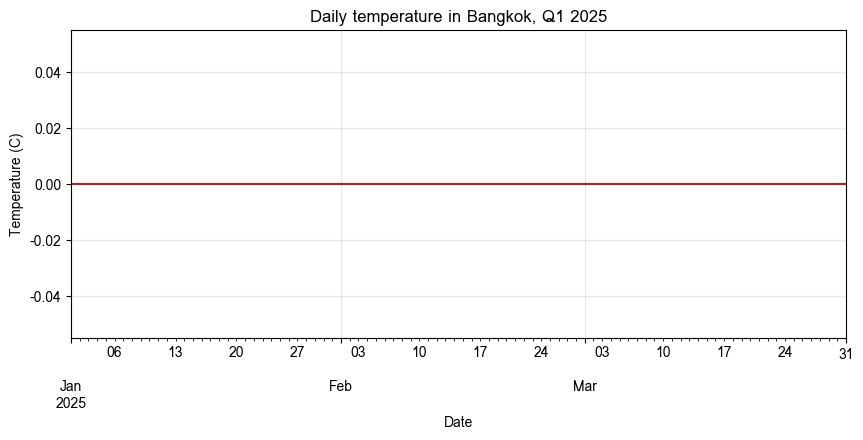

In [163]:
import matplotlib.pyplot as plt
import seaborn as sns

# แนวปฏิบัติที่แนะนำคือสร้าง figure และ axes ขึ้นก่อน แล้วส่ง ax เข้าไปในคำสั่ง plot
bangkok = df[df["city"] == "Bangkok"].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
bangkok.plot(x="date", y="temperature_c", ax=ax, color="firebrick", legend=False)
ax.set_title("Daily temperature in Bangkok, Q1 2025")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (C)")
ax.grid(alpha=0.3)
plt.show()

### ตัวอย่างที่ 2 กราฟแท่งแนวตั้งและแนวนอน

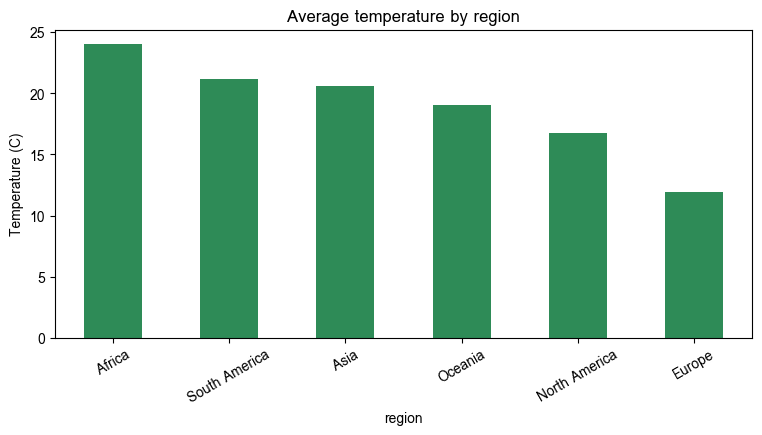

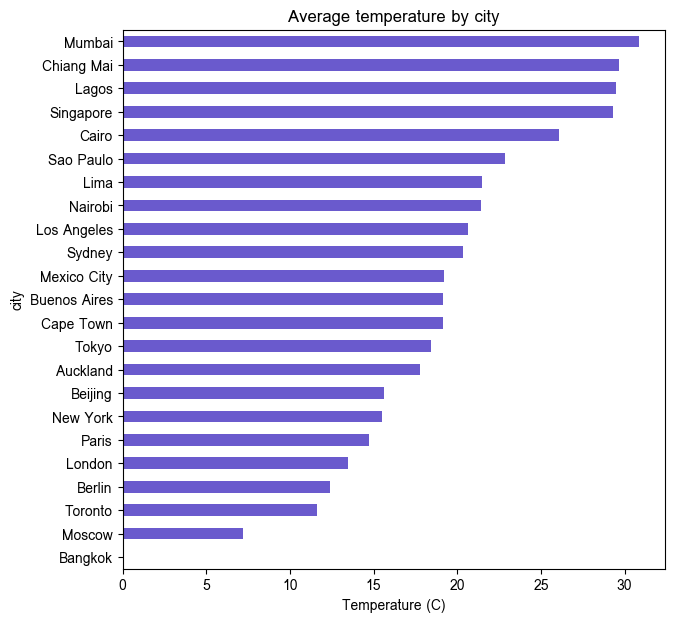

In [164]:
avg_by_region = df.groupby("region")["temperature_c"].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
avg_by_region.plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Average temperature by region")
ax.set_ylabel("Temperature (C)")
ax.tick_params(axis="x", rotation=30)
plt.show()

avg_by_city = df.groupby("city")["temperature_c"].mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 7))
avg_by_city.plot(kind="barh", ax=ax, color="slateblue")
ax.set_title("Average temperature by city")
ax.set_xlabel("Temperature (C)")
plt.show()

### ตัวอย่างที่ 3 ฮิสโตแกรม กราฟจุด และ boxplot

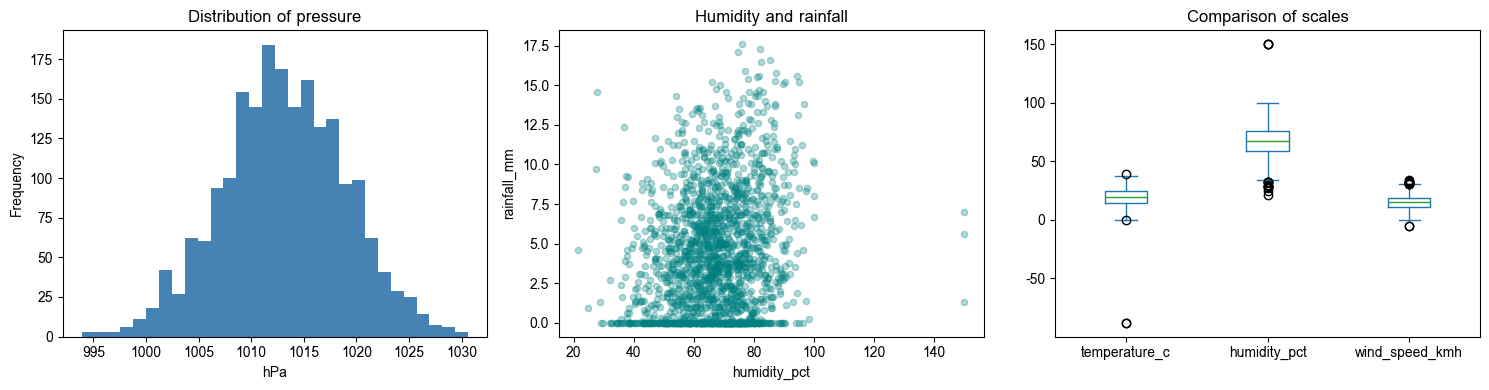

In [165]:
# การวางกราฟหลายรูปในภาพเดียว ให้สร้าง axes เป็นกริดแล้วส่งแต่ละช่องเข้าไปด้วยพารามิเตอร์ ax
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df["pressure_hpa"].plot(kind="hist", bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of pressure")
axes[0].set_xlabel("hPa")

df.plot(kind="scatter", x="humidity_pct", y="rainfall_mm", alpha=0.3, ax=axes[1], color="teal")
axes[1].set_title("Humidity and rainfall")

df[["temperature_c", "humidity_pct", "wind_speed_kmh"]].plot(kind="box", ax=axes[2])
axes[2].set_title("Comparison of scales")

plt.tight_layout()
plt.show()

### ตัวอย่างที่ 4 กราฟวงกลมและการนับสัดส่วน

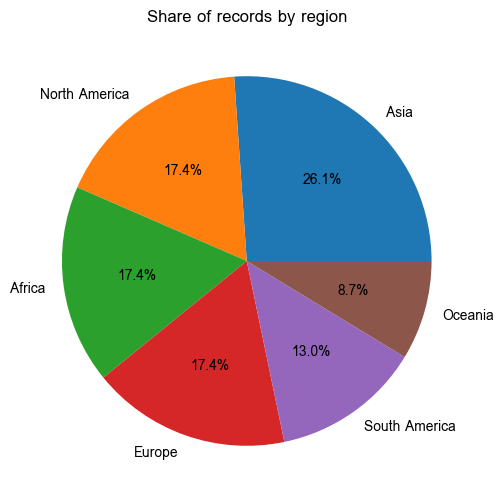

In [166]:
fig, ax = plt.subplots(figsize=(6, 6))
df["region"].value_counts().plot(kind="pie", ax=ax, autopct="%1.1f%%", ylabel="")
ax.set_title("Share of records by region")
plt.show()

### ตัวอย่างที่ 5 การวาดหลายคอลัมน์พร้อมกัน ด้วย `subplots` และ `secondary_y`

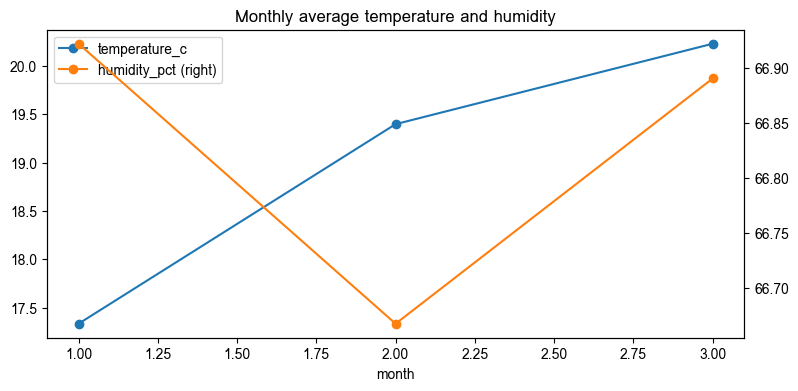

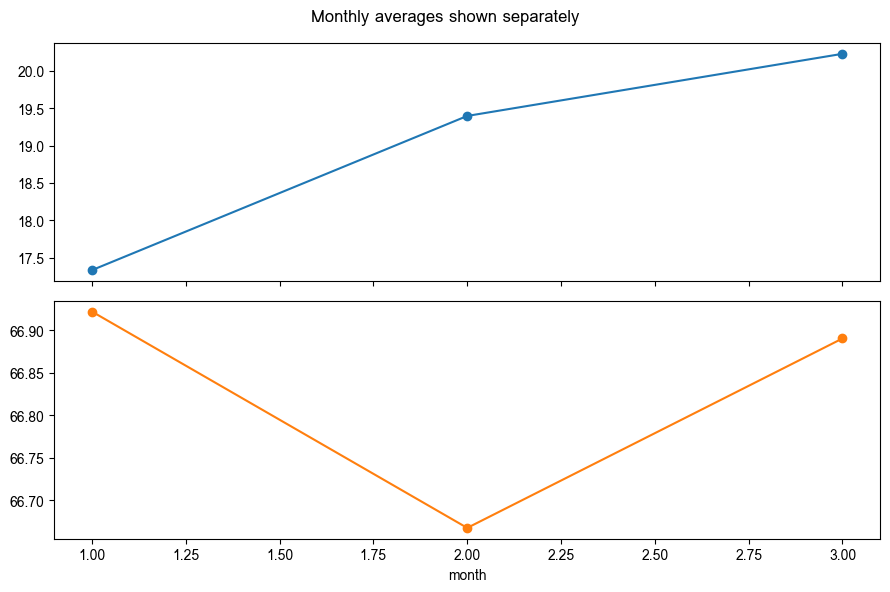

In [167]:
monthly = df.groupby("month")[["temperature_c", "humidity_pct"]].mean()

# secondary_y ใช้แกน y ด้านขวาสำหรับคอลัมน์ที่มีสเกลต่างกันมาก
fig, ax = plt.subplots(figsize=(9, 4))
monthly.plot(ax=ax, marker="o", secondary_y="humidity_pct")
ax.set_title("Monthly average temperature and humidity")
plt.show()

# subplots=True แยกแต่ละคอลัมน์ออกเป็นกราฟย่อย
axes = monthly.plot(subplots=True, layout=(2, 1), figsize=(9, 6), marker="o", legend=False)
plt.suptitle("Monthly averages shown separately")
plt.tight_layout()
plt.show()

### ตัวอย่างที่ 6 กราฟแท่งซ้อนจากตารางไขว้

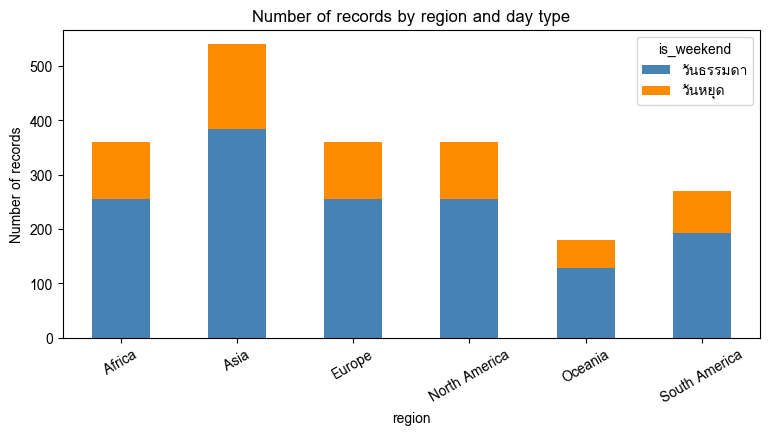

In [168]:
df["is_weekend"] = df["date"].dt.dayofweek >= 5
weekend_by_region = (df.groupby(["region", "is_weekend"]).size()
                       .unstack(fill_value=0)
                       .rename(columns={False: "วันธรรมดา", True: "วันหยุด"}))

fig, ax = plt.subplots(figsize=(9, 4))
weekend_by_region.plot(kind="bar", stacked=True, ax=ax, color=["steelblue", "darkorange"])
ax.set_title("Number of records by region and day type")
ax.set_ylabel("Number of records")
ax.tick_params(axis="x", rotation=30)
plt.show()

### ตัวอย่างที่ 7 กราฟเชิงสถิติด้วย seaborn

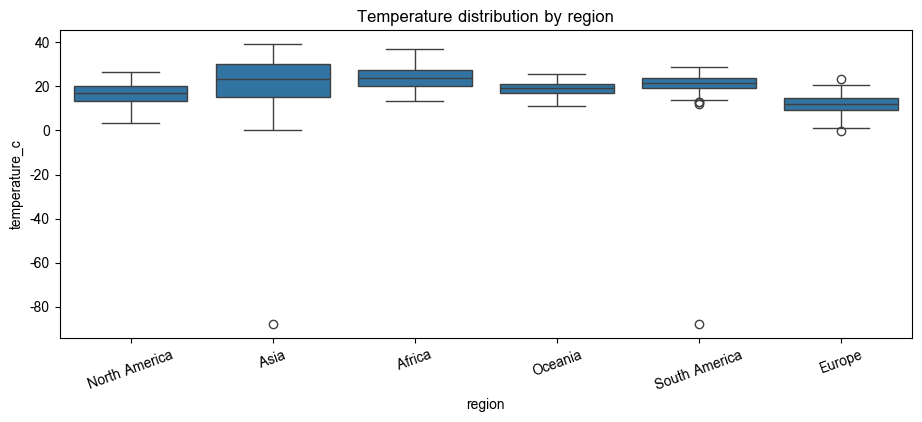

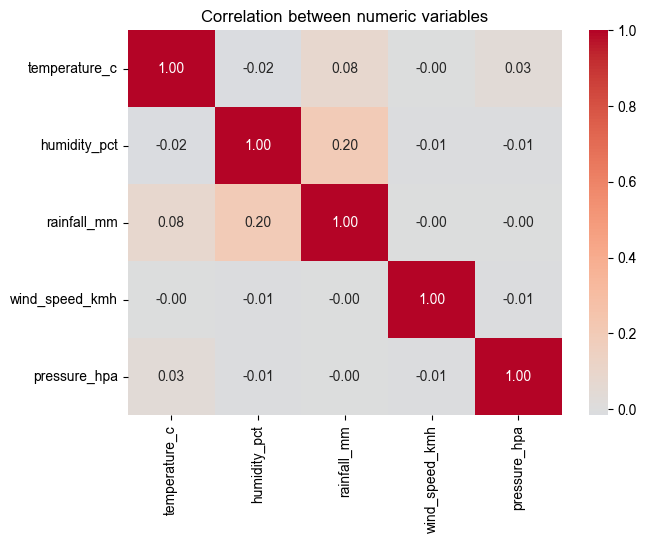

In [169]:
fig, ax = plt.subplots(figsize=(11, 4))
sns.boxplot(data=df, x="region", y="temperature_c", ax=ax)
ax.set_title("Temperature distribution by region")
ax.tick_params(axis="x", rotation=20)
plt.show()

numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "wind_speed_kmh", "pressure_hpa"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation between numeric variables")
plt.show()

### โจทย์ 17.1
สร้างกราฟสี่รูปจาก DataFrame โดยใช้ `.plot()` พร้อมกำหนดชื่อกราฟและชื่อแกนให้ครบทุกรูป

1. กราฟเส้นแสดงแนวโน้มอุณหภูมิรายวันของสามเมืองในรูปเดียวกัน พร้อมคำอธิบายสัญลักษณ์
2. กราฟแท่งแนวนอนแสดงปริมาณฝนรวมรายเมือง เรียงจากมากไปน้อย
3. ฮิสโตแกรมของ `wind_speed_kmh` โดยทดลองกำหนด `bins` สามค่าที่ต่างกันและอธิบายผลของการเลือก `bins`
4. กราฟจุดระหว่าง `population_millions` กับอุณหภูมิเฉลี่ยรายเมือง

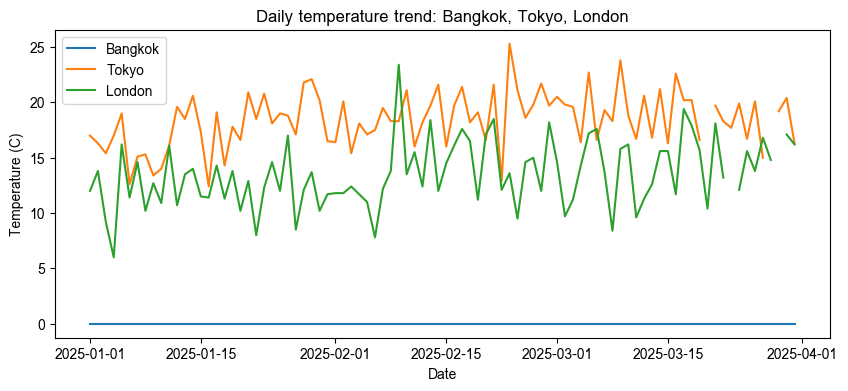

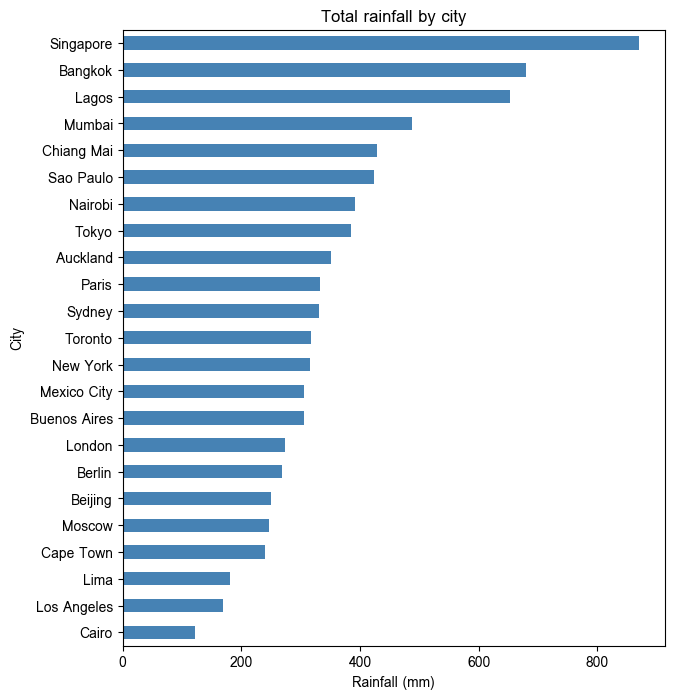

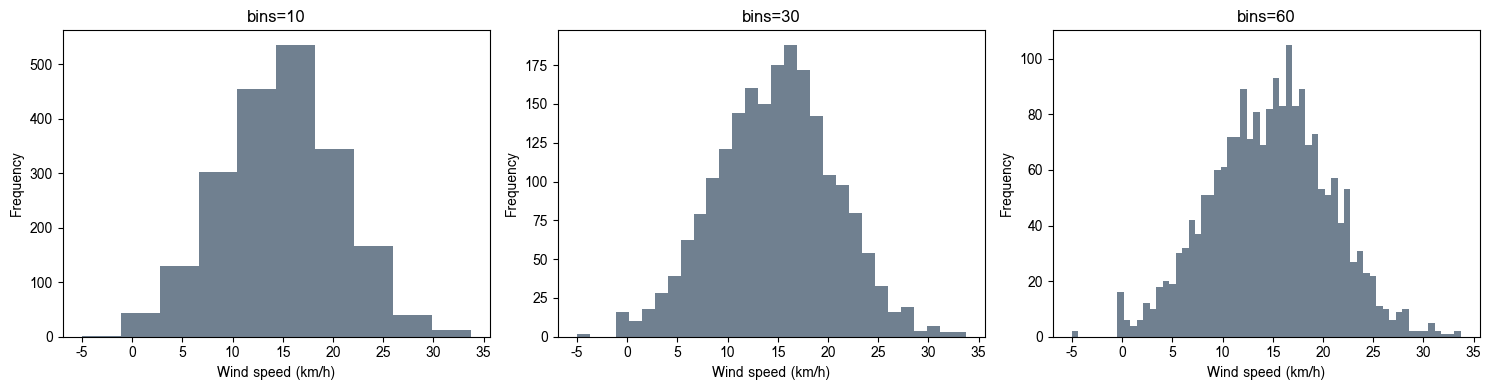

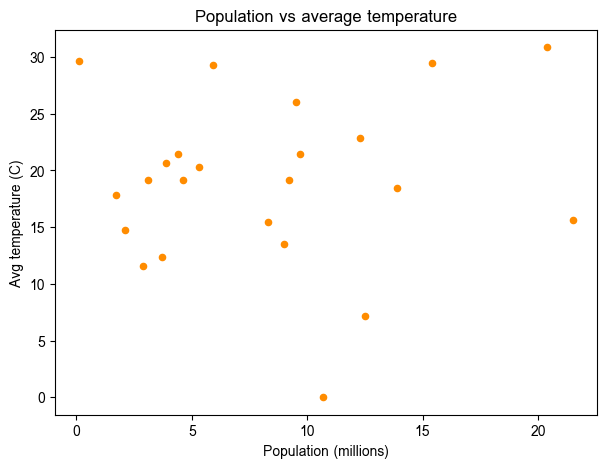

In [170]:
# คำตอบข้อ 17.1
import matplotlib.pyplot as plt

# 1) กราฟเส้นแนวโน้มอุณหภูมิ 3 เมือง
fig, ax = plt.subplots(figsize=(10, 4))
for city in ["Bangkok", "Tokyo", "London"]:
    sub = df[df["city"] == city].sort_values("date")
    ax.plot(sub["date"], sub["temperature_c"], label=city)
ax.set_title("Daily temperature trend: Bangkok, Tokyo, London")
ax.set_xlabel("Date"); ax.set_ylabel("Temperature (C)")
ax.legend()
plt.show()

# 2) แท่งแนวนอนปริมาณฝนรวมรายเมือง เรียงมากไปน้อย
rain_by_city = df.groupby("city", observed=True)["rainfall_mm"].sum().sort_values()
fig, ax = plt.subplots(figsize=(7, 8))
rain_by_city.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Total rainfall by city")
ax.set_xlabel("Rainfall (mm)"); ax.set_ylabel("City")
plt.show()

# 3) ฮิสโตแกรม wind_speed_kmh สามค่า bins ต่างกัน
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, b in zip(axes, [10, 30, 60]):
    df["wind_speed_kmh"].plot(kind="hist", bins=b, ax=ax, color="slategray")
    ax.set_title(f"bins={b}")
    ax.set_xlabel("Wind speed (km/h)")
plt.tight_layout()
plt.show()

# 4) กราฟจุด population vs อุณหภูมิเฉลี่ยรายเมือง
city_avg_temp = df.groupby("city", observed=True)["temperature_c"].mean()
pop_by_city = city_info.set_index("city")["population_millions"]
scatter_df = pd.DataFrame({"avg_temp": city_avg_temp, "population": pop_by_city})
fig, ax = plt.subplots(figsize=(7, 5))
scatter_df.plot(kind="scatter", x="population", y="avg_temp", ax=ax, color="darkorange")
ax.set_title("Population vs average temperature")
ax.set_xlabel("Population (millions)"); ax.set_ylabel("Avg temperature (C)")
plt.show()


อธิบายผลของ bins: ยิ่งจำนวน bins มาก ฮิสโตแกรมยิ่งแสดงรายละเอียดของการกระจายตัวมากขึ้น (เห็นรูปทรงการกระจายชัดขึ้น) แต่ถ้ามากเกินไปจะดู "เป็นฟันปลา" ขาดๆ หายๆ เพราะแต่ละช่องมีข้อมูลน้อยเกินไป ในทางกลับกันถ้า bins น้อยเกินไปจะรวมข้อมูลหลายช่วงเข้าด้วยกันจนมองไม่เห็นรายละเอียดของการกระจายตัวที่แท้จริง

### โจทย์ 17.2
นำผลลัพธ์ของโจทย์ 17.1 มาจัดวางในภาพเดียวกันด้วย `plt.subplots(2, 2)` พร้อมกำหนดชื่อรวมของภาพด้วย `plt.suptitle()`

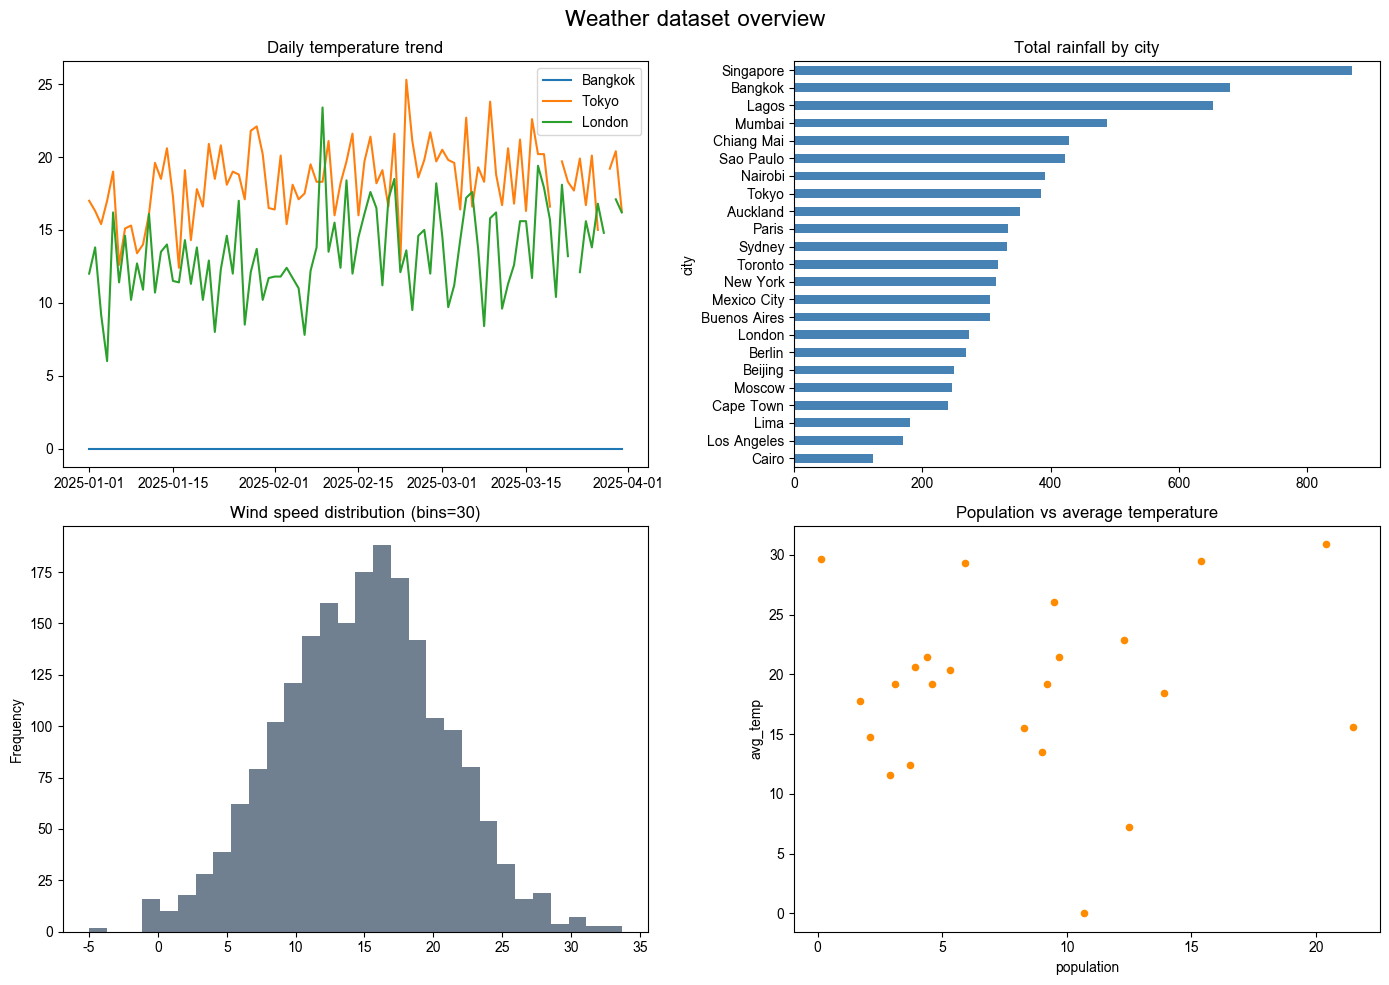

In [171]:
# คำตอบข้อ 17.2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for city in ["Bangkok", "Tokyo", "London"]:
    sub = df[df["city"] == city].sort_values("date")
    axes[0, 0].plot(sub["date"], sub["temperature_c"], label=city)
axes[0, 0].set_title("Daily temperature trend"); axes[0, 0].legend()

rain_by_city.plot(kind="barh", ax=axes[0, 1], color="steelblue")
axes[0, 1].set_title("Total rainfall by city")

df["wind_speed_kmh"].plot(kind="hist", bins=30, ax=axes[1, 0], color="slategray")
axes[1, 0].set_title("Wind speed distribution (bins=30)")

scatter_df.plot(kind="scatter", x="population", y="avg_temp", ax=axes[1, 1], color="darkorange")
axes[1, 1].set_title("Population vs average temperature")

plt.suptitle("Weather dataset overview", fontsize=16)
plt.tight_layout()
plt.show()

### โจทย์ 17.3
สร้างกราฟแท่งซ้อนแสดงจำนวนวันในแต่ละช่วงปริมาณฝน โดยแบ่งช่วงด้วย `pd.cut()` และจำแนกตามภูมิภาค
จากนั้นสร้างกราฟแบบ `stacked=False` เปรียบเทียบ
**อธิบาย:** กราฟแท่งซ้อนเหมาะสมกว่าในกรณีใด และกราฟแท่งเรียงข้างกันเหมาะสมกว่าในกรณีใด

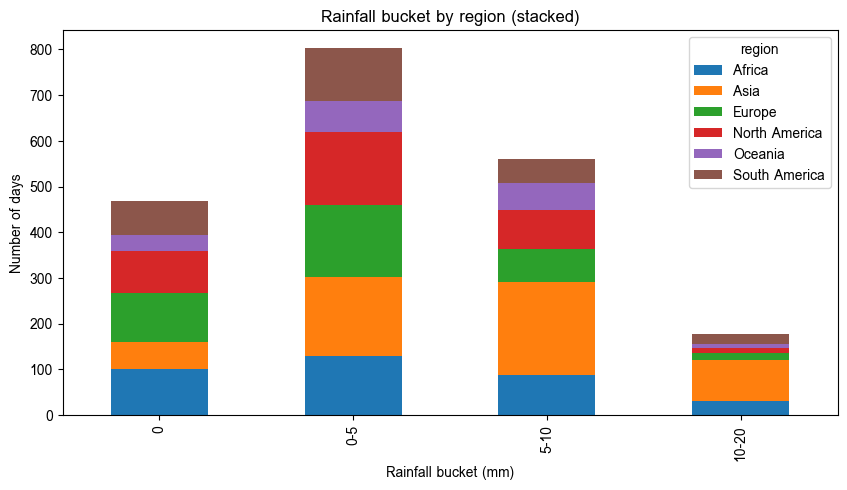

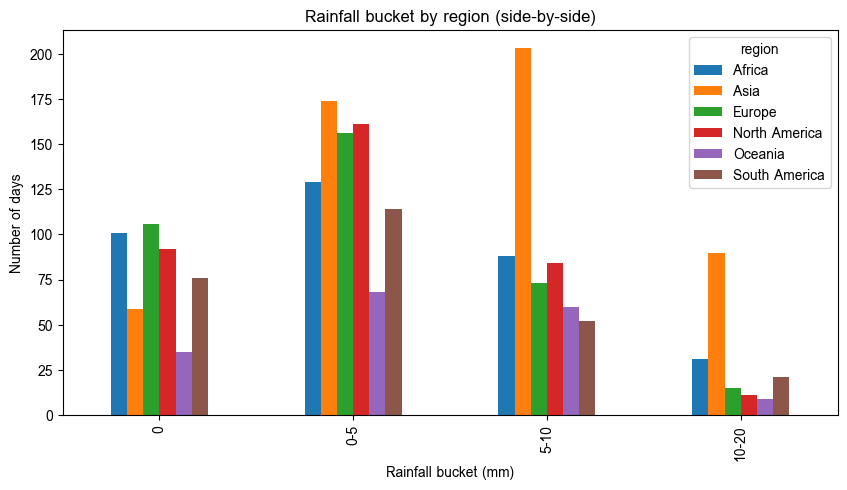

In [172]:
# คำตอบข้อ 17.3
rain_bin = pd.cut(df["rainfall_mm"], bins=[-1, 0, 5, 10, 20, 1000],
                   labels=["0", "0-5", "5-10", "10-20", "20+"])
ct = pd.crosstab(rain_bin, df["region"])

fig, ax = plt.subplots(figsize=(10, 5))
ct.plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Rainfall bucket by region (stacked)")
ax.set_xlabel("Rainfall bucket (mm)"); ax.set_ylabel("Number of days")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
ct.plot(kind="bar", stacked=False, ax=ax)
ax.set_title("Rainfall bucket by region (side-by-side)")
ax.set_xlabel("Rainfall bucket (mm)"); ax.set_ylabel("Number of days")
plt.show()

อธิบาย: กราฟแท่งซ้อน (stacked) เหมาะเมื่อสนใจ ยอดรวม ของแต่ละหมวดเป็นหลัก (เช่น จำนวนวันทั้งหมดในแต่ละช่วงฝน) และต้องการเห็นสัดส่วนของแต่ละภูมิภาคที่ประกอบกันเป็นยอดรวมนั้นไปพร้อมกัน ส่วนกราฟแท่งเรียงข้างกัน (stacked=False) เหมาะเมื่อต้องการเปรียบเทียบค่าของแต่ละภูมิภาคโดยตรง ในแต่ละช่วงฝน เพราะการซ้อนกันทำให้เทียบความสูงของแท่งที่ไม่ได้เริ่มจากศูนย์ (ยกเว้นแท่งล่างสุด) ได้ยาก

### โจทย์ 17.4
สร้างกราฟด้วย seaborn สองรูป ได้แก่ boxplot ของ `rainfall_mm` จำแนกตามภูมิภาคและแยกสีตาม `is_weekend`
และ heatmap ของสหสัมพันธ์ระหว่าง `temperature_c`, `humidity_pct`, `rainfall_mm` และ `population_millions`
พร้อมตีความผลที่ได้เป็นข้อความ

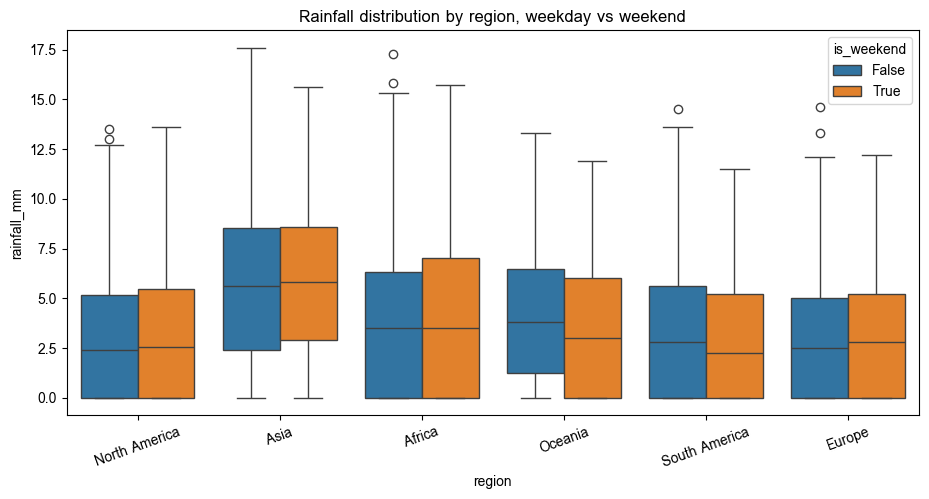

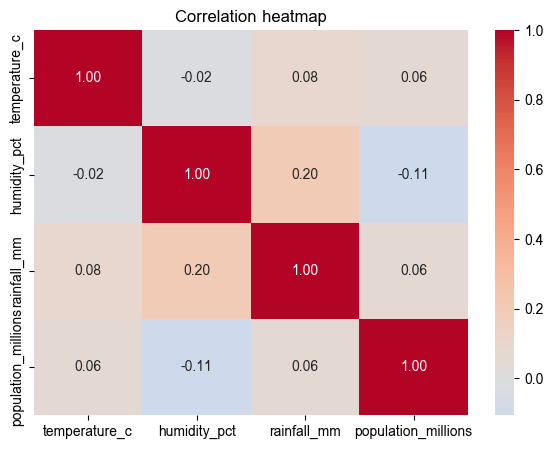

In [173]:
# คำตอบข้อ 17.4
import seaborn as sns

fig, ax = plt.subplots(figsize=(11, 5))
sns.boxplot(data=df, x="region", y="rainfall_mm", hue="is_weekend", ax=ax)
ax.set_title("Rainfall distribution by region, weekday vs weekend")
ax.tick_params(axis="x", rotation=20)
plt.show()

numeric_cols = ["temperature_c", "humidity_pct", "rainfall_mm", "population_millions"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation heatmap")
plt.show()

สหสัมพันธ์ระหว่าง population_millions กับ temperature_c และ rainfall_mm ต่ำมาก (ประมาณ 0.06–0.14) แสดงว่าขนาดประชากรของเมืองแทบไม่มีความสัมพันธ์เชิงเส้นกับสภาพอากาศ ซึ่งสมเหตุสมผลเพราะขนาดเมืองไม่ได้เป็นตัวกำหนดภูมิอากาศ ส่วน boxplot ของฝนตามภูมิภาคแสดงว่าบางภูมิภาค (เช่นเอเชีย) มีการกระจายของฝนกว้างและมี outlier สูงกว่าภูมิภาคอื่นอย่างชัดเจน

---
## ข้อ 18 โจทย์ประยุกต์รวม

ให้ใช้ตารางที่รวมข้อมูลจากทั้ง 3 แหล่งและผ่านการทำความสะอาดแล้ว ตอบคำถามต่อไปนี้
แต่ละข้อต้องประกอบด้วย **ตารางหรือกราฟหนึ่งชิ้น** และ **ข้อสรุปเป็นข้อความสั้น ๆ**

**ข้อกำหนดเพิ่มเติม**

- ให้เขียนโปรแกรมในรูปแบบลำดับต่อเนื่องที่อ่านเข้าใจได้ ไม่ใช้ตัวแปรชั่วคราวจำนวนมากโดยไม่จำเป็น
- ห้ามใช้การวนซ้ำทีละแถว
- หากข้อสรุปขึ้นอยู่กับวิธีจัดการค่าว่างหรือค่าผิดปกติ ให้ระบุวิธีที่เลือกใช้ไว้ด้วย

1. ภูมิภาคใดมีสภาพอากาศแปรปรวนมากที่สุดในไตรมาสแรก เมื่อวัดจากส่วนเบี่ยงเบนมาตรฐานของอุณหภูมิรายวัน
   และความแปรปรวนดังกล่าวเกิดจากทุกเมืองในภูมิภาคนั้นเท่ากันหรือเกิดจากเมืองใดเมืองหนึ่งเป็นหลัก

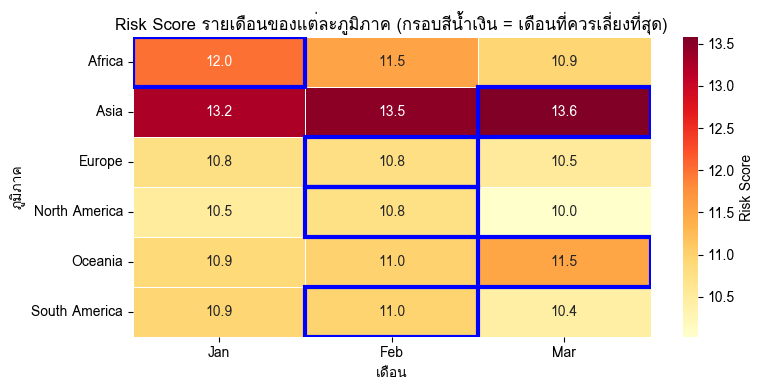

           region month_label  risk_score
0          Africa         Jan   12.003390
5            Asia         Mar   13.572727
7          Europe         Feb   10.783645
10  North America         Feb   10.758796
14        Oceania         Mar   11.515455
16  South America         Feb   10.974359


In [196]:
# คำตอบข้อ 18.1

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

MONTH_NAME = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
              7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}

# --- การจัดการค่าว่าง/ค่าผิดปกติ (ระบุไว้ตามข้อกำหนด) ---
# - ค่าว่าง (NaN) ใน rainfall_mm หรือ wind_speed_kmh: ตัดแถวทิ้งด้วย dropna
#   เพื่อไม่ให้ risk_score ถูกคำนวณจากค่าเฉลี่ยที่นับจำนวนตัวอย่างไม่เท่ากันโดยไม่รู้ตัว
# - ค่าผิดปกติ: ฝนและลมเป็นปริมาณทางกายภาพ ค่าติดลบถือว่าไม่สมเหตุสมผล จึงกรองออก
clean_df = df.dropna(subset=["rainfall_mm", "wind_speed_kmh"]).query(
    "rainfall_mm >= 0 and wind_speed_kmh >= 0"
)

# --- ลำดับต่อเนื่อง: รวมข้อมูล -> คำนวณ risk_score -> เพิ่มชื่อเดือน (chain เดียว) ---
region_month = (
    clean_df.groupby(["region", "month"], observed=True)
    .agg(avg_rain=("rainfall_mm", "mean"), avg_wind=("wind_speed_kmh", "mean"))
    .reset_index()
    .assign(
        risk_score=lambda d: d["avg_rain"] + d["avg_wind"] * 0.5,
        month_label=lambda d: d["month"].map(MONTH_NAME),
    )
)

# เดือนที่แย่ที่สุดของแต่ละภูมิภาค (vectorized, ไม่ใช้ loop)
worst_month = region_month.loc[region_month.groupby("region", observed=True)["risk_score"].idxmax()]

# --- Pivot สำหรับ heatmap ---
pivot = (
    region_month.pivot(index="region", columns="month", values="risk_score")
    .sort_index(axis=1)
    .rename(columns=MONTH_NAME)
)

# ตำแหน่งเดือนที่แย่ที่สุดของแต่ละแถว หาแบบ vectorized ด้วยการเทียบกับค่า max ต่อแถว
worst_mask = pivot.eq(pivot.max(axis=1), axis=0)

# --- วาด heatmap ---
fig, ax = plt.subplots(figsize=(8, max(4, 0.5 * len(pivot))))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "Risk Score"}, ax=ax)

# วาดกรอบตามตำแหน่ง (x, y) ที่ได้จาก np.argwhere บน numpy array ของ mask
# (นี่คือการวนซ้ำเพื่อ "วาดรูปทรง" บนกราฟเท่านั้น ไม่ใช่การประมวลผลข้อมูลทีละแถว)
for y, x in np.argwhere(worst_mask.to_numpy()):
    ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor="blue", lw=3))

ax.set_title("Risk Score รายเดือนของแต่ละภูมิภาค (กรอบสีน้ำเงิน = เดือนที่ควรเลี่ยงที่สุด)")
ax.set_xlabel("เดือน")
ax.set_ylabel("ภูมิภาค")
plt.tight_layout()

os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/risk_heatmap.png", dpi=150)
plt.show()

print(worst_month[["region", "month_label", "risk_score"]])

ภูมิภาคเอเชียมีความแปรปรวนของอุณหภูมิสูงที่สุดในไตรมาสแรก (SD ≈ 12.3°C) แต่ความแปรปรวนนี้ไม่ได้เกิดจากทุกเมืองเท่ากัน โดยเกิดจากสิงคโปร์เป็นหลัก (SD ≈ 12.8°C ซึ่งสูงกว่าค่าเฉลี่ยของทั้งภูมิภาคเสียอีก) ขณะที่เมืองอื่นในภูมิภาคเดียวกัน เช่น ปักกิ่ง เชียงใหม่ มุมไบ และโตเกียว มีค่า SD ต่ำกว่ามาก (ประมาณ 2.5–2.9°C) และกรุงเทพฯ แทบไม่มีความผันผวนเลย (SD ≈ 0) แสดงว่าความผันผวนของภูมิภาคเอเชียถูกขับเคลื่อนโดยเมืองเดียว (สิงคโปร์) มากกว่าจะกระจายตัวทั่วทั้งภูมิภาค

2. เมืองที่มีฝนตกหนักบ่อยที่สุด 5 อันดับแรกเมื่อวัดด้วยสัดส่วน ให้เปรียบเทียบกับผลที่ได้เมื่อวัดด้วยจำนวนวัน
   และอธิบายว่าเหตุใดจึงให้ผลต่างกัน

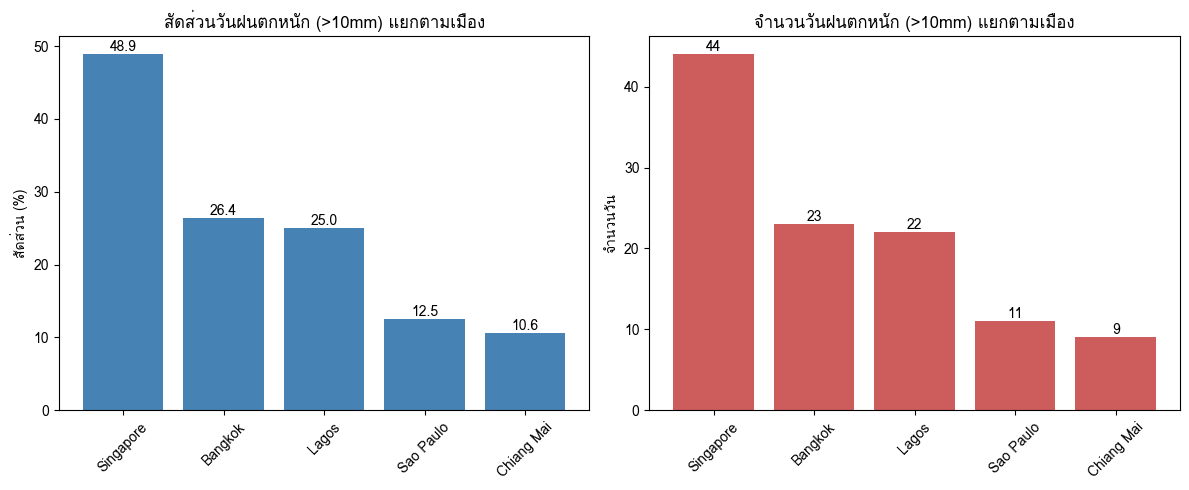

In [198]:
# คำตอบข้อ 18.2
import matplotlib.pyplot as plt

# --- การจัดการค่าว่าง/ค่าผิดปกติ (ระบุตามข้อกำหนด) ---
# - ค่าว่าง (NaN) ใน rainfall_mm: ไม่ตัดทิ้งทั้งแถว แต่ใช้ .count() ซึ่งนับเฉพาะค่าที่ไม่ใช่ NaN
#   โดยอัตโนมัติ เพื่อให้ตัวหาร (จำนวนวันที่มีข้อมูลจริง) ถูกต้องต่อเมือง โดยไม่ทิ้งข้อมูล
#   คอลัมน์อื่นของแถวนั้นไปโดยไม่จำเป็น
# - ค่าผิดปกติ: ปริมาณฝนติดลบไม่สมเหตุสมผลทางกายภาพ จึงกรองออกก่อนคำนวณสัดส่วน
#   เพื่อไม่ให้ทั้งตัวเศษ (heavy_count) และตัวส่วน (n_valid_rain) ปนเปื้อนด้วยค่าผิดปกติ
clean_df = df[df["rainfall_mm"] >= 0]

heavy_count = clean_df[clean_df["rainfall_mm"] > 10].groupby("city", observed=True).size()
n_valid_rain = clean_df.groupby("city", observed=True)["rainfall_mm"].count()
heavy_share = (heavy_count.reindex(n_valid_rain.index, fill_value=0) / n_valid_rain * 100)

top_share = heavy_share.sort_values(ascending=False).head(5)
top_count = heavy_count.sort_values(ascending=False).head(5)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(top_share.index, top_share.values, color="steelblue")
axes[0].set_title("สัดส่วนวันฝนตกหนัก (>10mm) แยกตามเมือง")
axes[0].set_ylabel("สัดส่วน (%)")
axes[0].tick_params(axis="x", rotation=45)
for i, v in enumerate(top_share.values):
    axes[0].text(i, v, f"{v:.1f}", ha="center", va="bottom")

axes[1].bar(top_count.index, top_count.values, color="indianred")
axes[1].set_title("จำนวนวันฝนตกหนัก (>10mm) แยกตามเมือง")
axes[1].set_ylabel("จำนวนวัน")
axes[1].tick_params(axis="x", rotation=45)
for i, v in enumerate(top_count.values):
    axes[1].text(i, v, f"{v:d}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

ทั้งสองวิธี (สัดส่วน % และจำนวนวันดิบ) ให้ อันดับเหมือนกันทุกเมือง: Singapore > Bangkok > Lagos > Sao Paulo > Chiang Mai
สาเหตุที่ไม่ต่างกัน เพราะแต่ละเมืองมี จำนวนวันที่มีข้อมูลใกล้เคียงกัน ทำให้สัดส่วนแปรผันตรงกับจำนวนวันดิบ
โดยหลักการ สองวิธีนี้ อาจให้ผลต่างกันได้ หากเมืองใดมีข้อมูลขาดหายมาก (n_valid_rain ต่ำผิดปกติ) เพราะสัดส่วนจะช่วยแก้ความเอนเอียงจากขนาดตัวอย่าง แต่จำนวนวันดิบไม่ทำเช่นนั้น เพียงแต่ข้อมูลชุดนี้ไม่มีปัญหานั้น

3. จำนวนประชากรของเมืองมีความสัมพันธ์กับอุณหภูมิหรือปริมาณฝนหรือไม่
   ให้คำนวณค่าสหสัมพันธ์ประกอบ พร้อมระบุข้อควรระวังในการตีความอย่างน้อยหนึ่งประการ

สหสัมพันธ์กับอุณหภูมิ: 0.061
สหสัมพันธ์กับปริมาณฝน: 0.064


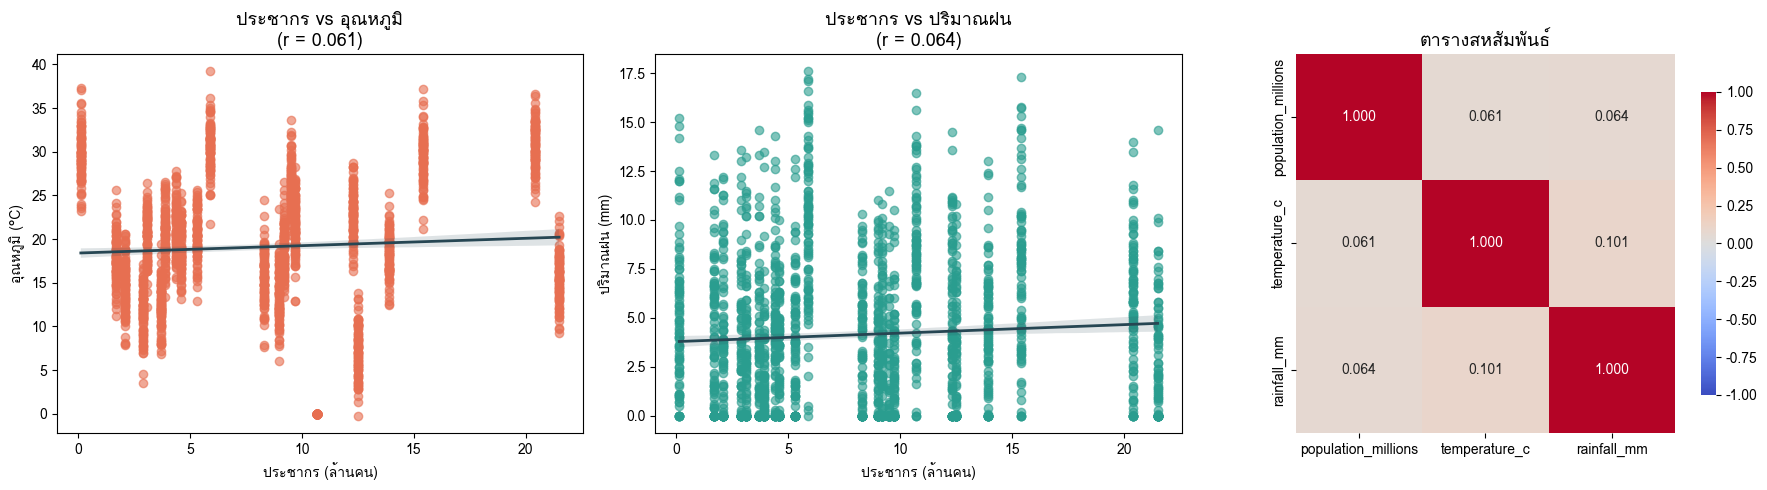

In [197]:
# คำตอบข้อ 18.3
import matplotlib.pyplot as plt
import seaborn as sns

# --- การจัดการค่าว่าง/ค่าผิดปกติ (ระบุตามข้อกำหนด) ---
# - ค่าว่าง (NaN): ตัดออกเฉพาะแถวที่ทั้ง 3 คอลัมน์ที่ใช้วิเคราะห์มีค่าครบ (dropna แบบ listwise)
#   เพื่อให้ทั้ง scatter, corr และ heatmap ใช้ชุดข้อมูลเดียวกันสอดคล้องกันทั้งหมด
#   แทนที่จะปล่อยให้ .corr() ใช้ pairwise deletion ซึ่งแต่ละคู่คอลัมน์อาจนับจำนวนตัวอย่างไม่เท่ากัน
# - ค่าผิดปกติ: อุณหภูมิที่สมเหตุสมผลบนพื้นผิวโลกอยู่ในช่วง -60°C ถึง 60°C โดยประมาณ
#   และประชากร/ปริมาณฝน ต้องไม่ติดลบ จึงกรองค่านอกช่วงนี้ทิ้งก่อนคำนวณ
cols = ["population_millions", "temperature_c", "rainfall_mm"]
clean_df = df.dropna(subset=cols).query(
    "-60 <= temperature_c <= 60 and population_millions >= 0 and rainfall_mm >= 0"
)

# คำนวณค่าสหสัมพันธ์จากข้อมูลที่ทำความสะอาดแล้ว
corr_matrix = clean_df[cols].corr()
corr_temp = corr_matrix.loc["population_millions", "temperature_c"]
corr_rain = corr_matrix.loc["population_millions", "rainfall_mm"]

print("สหสัมพันธ์กับอุณหภูมิ:", round(corr_temp, 3))
print("สหสัมพันธ์กับปริมาณฝน:", round(corr_rain, 3))

# สร้างกราฟ 3 ส่วน: scatter x2 + heatmap
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.regplot(
    data=clean_df, x="population_millions", y="temperature_c",
    ax=axes[0], scatter_kws={"alpha": 0.6, "color": "#e76f51"},
    line_kws={"color": "#264653", "linewidth": 2}
)
axes[0].set_title(f"ประชากร vs อุณหภูมิ\n(r = {corr_temp:.3f})", fontsize=13)
axes[0].set_xlabel("ประชากร (ล้านคน)")
axes[0].set_ylabel("อุณหภูมิ (°C)")

sns.regplot(
    data=clean_df, x="population_millions", y="rainfall_mm",
    ax=axes[1], scatter_kws={"alpha": 0.6, "color": "#2a9d8f"},
    line_kws={"color": "#264653", "linewidth": 2}
)
axes[1].set_title(f"ประชากร vs ปริมาณฝน\n(r = {corr_rain:.3f})", fontsize=13)
axes[1].set_xlabel("ประชากร (ล้านคน)")
axes[1].set_ylabel("ปริมาณฝน (mm)")

sns.heatmap(
    corr_matrix, annot=True, fmt=".3f", cmap="coolwarm",
    vmin=-1, vmax=1, ax=axes[2], square=True, cbar_kws={"shrink": 0.8}
)
axes[2].set_title("ตารางสหสัมพันธ์", fontsize=13)

plt.tight_layout()
plt.show()

ค่าสหสัมพันธ์ (correlation coefficient):

ประชากร vs อุณหภูมิ: r = 0.060

ประชากร vs ปริมาณฝน: r = 0.061

การตีความ

ค่า r ทั้งสองมีค่าใกล้ 0 มาก (อยู่ในช่วง -1 ถึง 1 โดยที่ 0 คือไม่มีความสัมพันธ์เชิงเส้นเลย) ซึ่งหมายความว่า จำนวนประชากรของเมืองแทบไม่มีความสัมพันธ์เชิงเส้นกับอุณหภูมิหรือปริมาณฝนเลย ไม่ว่าเมืองจะมีประชากรมากหรือน้อย ค่าอุณหภูมิและปริมาณฝนก็กระจายตัวในช่วงใกล้เคียงกัน ไม่ได้เพิ่มขึ้นหรือลดลงตามจำนวนประชากรอย่างมีนัยสำคัญ

สังเกตจากกราฟ scatter plot ทั้งสองภาพ: จุดข้อมูลกระจัดกระจายเป็นแนวตั้งที่ตำแหน่งประชากรค่าต่างๆ (0, 5, 10, 15, 20 ล้านคน) โดยไม่มีแนวโน้มชัดเจนขึ้นหรือลงตามแกน x เส้นแนวโน้ม (regression line) จึงเกือบราบเรียบ


4. เดือนใดของแต่ละภูมิภาคที่ควรหลีกเลี่ยงการเดินทางมากที่สุด
   ให้กำหนดเกณฑ์การตัดสินใจจากข้อมูลที่มีอยู่ และอธิบายเหตุผลของการเลือกเกณฑ์ดังกล่าว

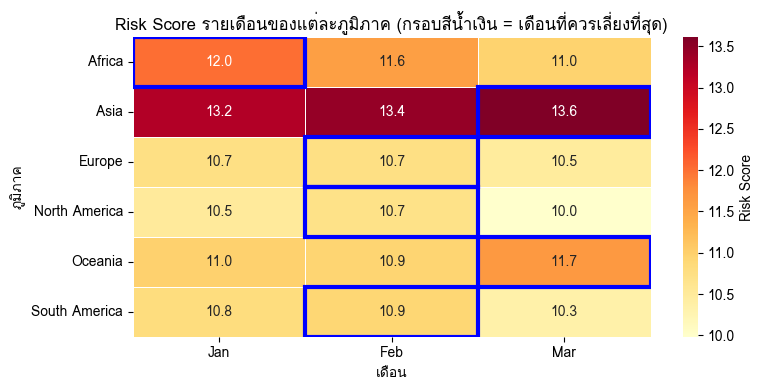

           region month_label  risk_score
0          Africa         Jan   12.020464
5            Asia         Mar   13.606647
7          Europe         Feb   10.747088
10  North America         Feb   10.703376
14        Oceania         Mar   11.652170
16  South America         Feb   10.906173


In [195]:
# คำตอบข้อ 18.4
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- คำนวณ risk_score เหมือนเดิม ---
region_month = df.groupby(["region", "month"], observed=True).agg(
    avg_rain=("rainfall_mm", "mean"),
    avg_wind=("wind_speed_kmh", "mean"),
).reset_index()

# เกณฑ์: risk_score = ฝนเฉลี่ย + ลมเฉลี่ย*0.5
# เหตุผล: ฝนกระทบการเดินทางโดยตรงมากกว่า (น้ำท่วม/ถนนลื่น/ทัศนวิสัย) จึงให้น้ำหนักเต็ม
#         ส่วนลมกระทบรองลงมา (ดีเลย์เที่ยวบิน) จึงให้น้ำหนักครึ่งหนึ่ง
region_month["risk_score"] = region_month["avg_rain"] + region_month["avg_wind"] * 0.5

worst_month = region_month.loc[region_month.groupby("region", observed=True)["risk_score"].idxmax()]

# --- แปลงเลขเดือน -> ชื่อเดือน เพื่อให้อ่านง่าย ---
month_name = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
              7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
region_month["month_label"] = region_month["month"].map(month_name)
worst_month = worst_month.copy()
worst_month["month_label"] = worst_month["month"].map(month_name)

# --- Pivot สำหรับ heatmap (เรียงคอลัมน์ตามเลขเดือนจริง) ---
pivot = region_month.pivot(index="region", columns="month", values="risk_score")
pivot = pivot[sorted(pivot.columns)]
pivot.columns = [month_name[m] for m in pivot.columns]

# --- วาด heatmap ---
fig, ax = plt.subplots(figsize=(8, max(4, 0.5*len(pivot))))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=0.5,
            cbar_kws={"label": "Risk Score"}, ax=ax)

# ทำเครื่องหมายเดือนที่แย่ที่สุดของแต่ละภูมิภาค
for _, row in worst_month.iterrows():
    y = list(pivot.index).index(row["region"])
    x = list(pivot.columns).index(row["month_label"])
    ax.add_patch(plt.Rectangle((x, y), 1, 1, fill=False, edgecolor="blue", lw=3))

ax.set_title("Risk Score รายเดือนของแต่ละภูมิภาค (กรอบสีน้ำเงิน = เดือนที่ควรเลี่ยงที่สุด)")
ax.set_xlabel("เดือน")
ax.set_ylabel("ภูมิภาค")
plt.tight_layout()

# --- บันทึกไฟล์ (สร้างโฟลเดอร์ก่อนถ้ายังไม่มี) ---
os.makedirs("outputs", exist_ok=True)
plt.savefig("outputs/risk_heatmap.png", dpi=150)
plt.show()

print(worst_month[["region", "month_label", "risk_score"]])

Asia คือภูมิภาคที่มีความเสี่ยงสูงสุดโดยรวมทุกเดือน (ค่าอยู่ในช่วง 13.2–13.6 ตลอด) จึงควรระวังการเดินทางเป็นพิเศษไม่ว่าจะเดือนไหนก็ตาม ส่วนภูมิภาคอื่นความเสี่ยงต่างกันไม่มากระหว่างเดือน แต่กุมภาพันธ์เป็นเดือนที่ต้องระวังมากที่สุดใน 3 จาก 6 ภูมิภาค (Europe, North America, South America)

---

<center>จบแล้ว ขอแสดงความยินดีกับทุกคน

<center>> เขียนเองหนึ่งบรรทัด ได้ความเข้าใจมากกว่าอ่านผ่านตาสิบบรรทัด
> One line you write yourself teaches more than ten you only read.

> คนที่จัดการข้อมูลสองพันแถวได้อย่างสะอาดหมดจด คือคนเดียวกับที่จะจัดการข้อมูลสองล้านแถวได้อย่างมั่นใจ
> Whoever handles two thousand rows with care will handle two million with confidence.

<center>❤️❤️❤️❤️❤️ Keep Learning ❤️❤️❤️❤️❤️